<a href="https://www.kaggle.com/code/avikdas567/planetary-defense-asteroid-hazard-classification?scriptVersionId=337279029" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Planetary Defense Analysis and Hazard Classification Framework for Near-Earth Asteroids
---

## Theoretical Astrophysics Framework and Mathematical Formulation

Near-Earth Objects (NEOs) are small Solar System bodies whose orbits bring them into proximity with Earth. A subset of these objects, classified as Potentially Hazardous Asteroids (PHAs), pose potential impact risks to Earth based on their physical scale and orbital geometry.

## 1. Keplerian Orbital Mechanics
The motion of an asteroid around the Sun is governed by Kepler's laws of planetary motion and Newton's law of universal gravitation. The orbital period $P$ (in years) relates to the semi-major axis $a$ (in astronomical units, AU) via Kepler's Third Law:

$$P^2 = \frac{4\pi^2}{G(M_\odot + m)} a^3 \approx a^3$$

Where $G$ is the gravitational constant, $M_\odot$ is the mass of the Sun, and $m \ll M_\odot$ is the mass of the asteroid.

The orbital eccentricity $e$ defines the ellipticity of the trajectory. The perihelion distance $q$ (closest distance to the Sun) and aphelion distance $Q$ (farthest distance from the Sun) are calculated as:

$$q = a(1 - e)$$
$$Q = a(1 + e)$$

The orbital velocity $v$ at any radial distance $r$ from the Sun is governed by the Vis-Viva equation:

$$v^2 = G M_\odot \left( \frac{2}{r} - \frac{1}{a} \right)$$

## 2. Tisserand Parameter
The Tisserand parameter relative to Jupiter ($T_J$) is a conserved dynamical quantity in the restricted three-body problem, utilized to classify small body orbits and assess orbital stability against Jovian perturbations:

$$T_J = \frac{a_J}{a} + 2 \cos(i) \sqrt{\frac{a}{a_J} (1 - e^2)}$$

Where $a_J \approx 5.2044 \text{ AU}$ is the semi-major axis of Jupiter, and $i$ is the orbital inclination in radians relative to the ecliptic plane. Asteroids generally satisfy $T_J > 3.0$, whereas comets exhibit $T_J < 3.0$.

## 3. Absolute Magnitude and Physical Diameter Relationship
The absolute visual magnitude $H$ represents the visual magnitude an object would have at a distance of $1 \text{ AU}$ from both the Sun and the observer, at a phase angle of zero degrees. The effective diameter $D$ (in kilometers) is related to $H$ and the geometric albedo $p_V$ by:

$$D = \frac{1329}{\sqrt{p_V}} 10^{-0.2 H}$$

When the exact albedo is unmeasured, standard astronomical bounds ($0.05 \le p_V \le 0.25$) establish the minimum and maximum estimated diameter range:

$$D_{\min} = \frac{1329}{\sqrt{0.25}} 10^{-0.2 H} = 2658 \times 10^{-0.2 H} \text{ km}$$
$$D_{\max} = \frac{1329}{\sqrt{0.05}} 10^{-0.2 H} = 5943.4 \times 10^{-0.2 H} \text{ km}$$

## 4. Formal NASA Potentially Hazardous Asteroid (PHA) Criteria
NASA's Center for Near Earth Object Studies (CNEOS) defines a Potentially Hazardous Asteroid via a strict analytical boundary condition:

$$\text{PHA} = \mathbb{I}(\text{MOID} \le 0.05 \text{ AU}) \times \mathbb{I}(H \le 22.0)$$

Where $\text{MOID}$ is the Minimum Orbit Intersection Distance relative to Earth, and $H \le 22.0$ guarantees a minimum diameter threshold of approximately $140 \text{ meters}$. An object satisfying both criteria possesses the physical capacity to survive atmospheric entry and cause severe localized or regional catastrophic damage upon impact.


In [1]:
import os
import sys
import ast
import json
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    f1_score, precision_score, recall_score, log_loss,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Suppress all system and library warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONHASHSEED'] = '42'

# Global Seed Initialization for Complete Pipeline Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# High Resolution Global Plot Styling Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['figure.dpi'] = 150

# Custom Astronomical Deep Space Palette
DEEP_SPACE_PALETTE = ['#0B1D3A', '#1A365D', '#2B6CB0', '#319795', '#D69E2E', '#DD6B20', '#E53E3E', '#805AD5']
sns.set_palette(DEEP_SPACE_PALETTE)

print("Execution environment configured successfully.")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Acceleration Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")



Execution environment configured successfully.
PyTorch Version: 2.10.0+cu128
CUDA Acceleration Available: True
Device Name: Tesla T4


# Data Ingestion and Structural Data Audit

The primary dataset is ingested from the specified Kaggle input repository path. A comprehensive automated audit evaluates sample dimensions, memory footprint, column data types, missingness counts, and target class balance.

Let $N$ denote the total number of asteroid records ($N = 2000$) and $P$ denote the original feature dimensionality ($P = 39$). Missingness indicators for each feature vector $x_j$ are defined by:

$$M(x_j) = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(x_{ij} = \text{null})$$


In [2]:
dataset_path = "/kaggle/input/datasets/lion8beasttmkc/nasa-near-earth-asteroids-dataset/asteroids_data.csv"
if not os.path.exists(dataset_path):
    dataset_path = "asteroids_data.csv"

df_raw = pd.read_csv(dataset_path)

print(f"Primary Dataset Path: {dataset_path}")
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

audit_summary = pd.DataFrame({
    'Data_Type': df_raw.dtypes,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Percentage': (df_raw.isnull().sum() / len(df_raw)) * 100.0,
    'Unique_Values': df_raw.nunique()
})

print("\nData Audit Summary Table:")
display(audit_summary)

print("\nTarget Class Breakdown (potentially_hazardous):")
target_counts = df_raw['potentially_hazardous'].value_counts()
target_props = df_raw['potentially_hazardous'].value_counts(normalize=True) * 100
for val in [False, True]:
    print(f"  Class {val}: {target_counts[val]} objects ({target_props[val]:.2f}%)")



Primary Dataset Path: /kaggle/input/datasets/lion8beasttmkc/nasa-near-earth-asteroids-dataset/asteroids_data.csv
Dataset Shape: 2000 rows, 39 columns

Data Audit Summary Table:


,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
id,int64,0,0.00,2000
neo_id,int64,0,0.00,2000
name,object,0,0.00,2000
short_name,object,1833,91.65,167
designation,int64,0,0.00,2000
nasa_url,object,0,0.00,2000
magnitude,float64,0,0.00,634
potentially_hazardous,bool,0,0.00,2
close_approach_data,object,0,0.00,1815
sentry,bool,0,0.00,2



Target Class Breakdown (potentially_hazardous):
  Class False: 1467 objects (73.35%)
  Class True: 533 objects (26.65%)


## Observations and Data Audit Inferences
The structural data audit confirms that 37 out of 39 columns exhibit complete records with zero missing values. The binary target `potentially_hazardous` contains 1,467 non-hazardous objects (73.35%) and 533 potentially hazardous asteroids (26.65%), establishing a manageable class imbalance ratio of approximately 2.75 to 1. Incomplete features such as `short_name` (91.65% missing) and `sentry_data` (99.85% missing) reflect specialized records that are non-null exclusively for actively monitored or designated objects.


# Complex JSON Parsing and Physics Informed Feature Engineering

The dataset contains a serialized string column `close_approach_data` detailing historical and forecasted planetary encounters. We extract fine-grained close approach telemetry:

1. Encounter Frequency ($N_{\text{enc}}$): Total close approaches recorded for object $i$.
2. Global Minimum Miss Distance ($d_{\min}$): Minimum miss distance in kilometers across all planetary encounters.
3. Maximum Encounter Velocity ($v_{\max}$): Peak relative velocity in $\text{km/s}$ during encounters.
4. Earth-Specific Minimum Distance ($d_{\min, \text{Earth}}$): Minimum miss distance in kilometers specifically during close encounters with Earth.

Furthermore, we engineer domain-specific astronomical features using orbital mechanics equations:

* Kepler Period Discrepancy: $R_{P} = \frac{P_{\text{observed}}}{a^{1.5} \times 365.256}$
* Normalized Specific Orbital Energy: $\epsilon_{\text{norm}} = -\frac{1}{2a}$
* Orbital Angular Momentum Index: $h_{\text{index}} = \sqrt{a (1 - e^2)}$
* Relativistic Perihelion to Aphelion Velocity Ratio: $V_{\text{ratio}} = \frac{v_p}{v_a} = \sqrt{\frac{2/q - 1/a}{2/Q - 1/a}} = \sqrt{\frac{1+e}{1-e}}$
* Logarithmic Stabilization: Continuous physical parameters exhibit high positive skewness. We apply natural logarithm transformations $\log(1 + x)$ to normalize distributions.


In [3]:
class AstrophysicsFeatureExtractor:
    def __init__(self):
        pass

    def transform(self, df):
        data = df.copy()
        
        cad_counts = []
        min_miss_km = []
        max_rel_vel_kms = []
        mean_rel_vel_kms = []
        earth_encounters = []
        earth_min_miss_km = []
        
        for idx, row in data.iterrows():
            try:
                cad_list = ast.literal_eval(row['close_approach_data'])
                cad_counts.append(len(cad_list))
                if len(cad_list) > 0:
                    dists = [float(item['miss_distance']['kilometers']) for item in cad_list]
                    vels = [float(item['relative_velocity']['kilometers_per_second']) for item in cad_list]
                    min_miss_km.append(min(dists))
                    max_rel_vel_kms.append(max(vels))
                    mean_rel_vel_kms.append(np.mean(vels))
                    
                    earth_cads = [item for item in cad_list if item.get('orbiting_body') == 'Earth']
                    earth_encounters.append(len(earth_cads))
                    if len(earth_cads) > 0:
                        earth_min_miss_km.append(min([float(item['miss_distance']['kilometers']) for item in earth_cads]))
                    else:
                        earth_min_miss_km.append(np.nan)
                else:
                    min_miss_km.append(np.nan)
                    max_rel_vel_kms.append(np.nan)
                    mean_rel_vel_kms.append(np.nan)
                    earth_encounters.append(0)
                    earth_min_miss_km.append(np.nan)
            except Exception:
                cad_counts.append(0)
                min_miss_km.append(np.nan)
                max_rel_vel_kms.append(np.nan)
                mean_rel_vel_kms.append(np.nan)
                earth_encounters.append(0)
                earth_min_miss_km.append(np.nan)

        data['cad_total_encounters'] = cad_counts
        data['cad_min_miss_dist_km'] = min_miss_km
        data['cad_max_rel_velocity_kms'] = max_rel_vel_kms
        data['cad_mean_rel_velocity_kms'] = mean_rel_vel_kms
        data['cad_earth_encounters'] = earth_encounters
        data['cad_earth_min_miss_dist_km'] = earth_min_miss_km

        # Impute missing encounter distance values with dataset medians
        data['cad_min_miss_dist_km'] = data['cad_min_miss_dist_km'].fillna(data['cad_min_miss_dist_km'].median())
        data['cad_max_rel_velocity_kms'] = data['cad_max_rel_velocity_kms'].fillna(data['cad_max_rel_velocity_kms'].median())
        data['cad_mean_rel_velocity_kms'] = data['cad_mean_rel_velocity_kms'].fillna(data['cad_mean_rel_velocity_kms'].median())
        data['cad_earth_min_miss_dist_km'] = data['cad_earth_min_miss_dist_km'].fillna(data['cad_min_miss_dist_km'])

        # Mean diameter and physical dimensions
        data['diameter_mean_m'] = (data['diameter_min_m'] + data['diameter_max_m']) / 2.0
        data['diameter_span_m'] = data['diameter_max_m'] - data['diameter_min_m']

        # Keplerian dynamics features
        kepler_p_days = (data['semi_major_axis'] ** 1.5) * 365.256
        data['period_kepler_ratio'] = data['orbital_period'] / (kepler_p_days + 1e-9)
        data['orbital_energy_norm'] = -1.0 / (2.0 * data['semi_major_axis'] + 1e-9)
        data['angular_momentum_factor'] = np.sqrt(np.maximum(0, data['semi_major_axis'] * (1.0 - data['eccentricity']**2)))
        
        # Velocity ratio perihelion vs aphelion
        v_peri = np.sqrt(np.abs(2.0 / (data['perihelion_distance'] + 1e-9) - 1.0 / (data['semi_major_axis'] + 1e-9)))
        v_aphe = np.sqrt(np.abs(2.0 / (data['aphelion_distance'] + 1e-9) - 1.0 / (data['semi_major_axis'] + 1e-9)))
        data['velocity_ratio_p2a'] = v_peri / (v_aphe + 1e-9)

        # NASA Analytical Threshold Rules
        data['is_moid_sub_005'] = (data['min_orbit_intersection'] <= 0.05).astype(int)
        data['is_mag_sub_22'] = (data['magnitude'] <= 22.0).astype(int)
        data['pha_nasa_rule_match'] = (data['is_moid_sub_005'] & data['is_mag_sub_22']).astype(int)

        # Logarithmic transformations for heavily skewed attributes
        skewed_cols = ['diameter_mean_m', 'data_arc_days', 'observations_used', 
                       'min_orbit_intersection', 'cad_min_miss_dist_km', 'cad_earth_min_miss_dist_km']
        for c in skewed_cols:
            data[f'log_{c}'] = np.log1p(np.maximum(0, data[c]))

        return data

extractor = AstrophysicsFeatureExtractor()
df_proc = extractor.transform(df_raw)
print(f"Feature Engineering Complete. Total Processed Columns: {df_proc.shape[1]}")



Feature Engineering Complete. Total Processed Columns: 60


## Feature Engineering Inferences
Parsing the nested `close_approach_data` successfully uncovers historical encounter frequencies and minimum miss distances for each celestial body. Combining these telemetry metrics with physical dimensions and Keplerian invariants yields a high dimensional representation that captures both the static orbital geometry and dynamic close encounter profile of each near-Earth object.


# Rigorous Statistical Analysis and Scientific Hypothesis Testing

To establish whether Potentially Hazardous Asteroids (PHAs) exhibit statistically significant distribution shifts compared to Non-PHAs, we conduct formal statistical hypothesis tests:

1. Two-Sample Kolmogorov-Smirnov Test: Evaluates whether two empirical distributions are drawn from identical continuous distributions:

$$D = \sup_x |F_1(x) - F_2(x)|$$

2. Mann-Whitney U Test: Non-parametric assessment of whether randomly selected values from one population are stochastically larger than those from another:

$$U = R_1 - \frac{n_1(n_1 + 1)}{2}$$

3. Pearson Chi-Square Test of Independence: Quantifies association between categorical orbit family classifications and hazard status:

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$


In [4]:
pha_mask = df_proc['potentially_hazardous'] == True
non_pha_mask = df_proc['potentially_hazardous'] == False

test_features = [
    'magnitude', 'min_orbit_intersection', 'eccentricity', 
    'semi_major_axis', 'inclination', 'jupiter_tisserand',
    'diameter_mean_m', 'cad_max_rel_velocity_kms', 'cad_earth_min_miss_dist_km'
]

stats_results = []

for feat in test_features:
    pha_vals = df_proc.loc[pha_mask, feat].dropna()
    non_pha_vals = df_proc.loc[non_pha_mask, feat].dropna()
    
    ks_stat, ks_pval = stats.ks_2samp(pha_vals, non_pha_vals)
    mw_stat, mw_pval = stats.mannwhitneyu(pha_vals, non_pha_vals, alternative='two-sided')
    
    stats_results.append({
        'Feature': feat,
        'PHA_Mean': pha_vals.mean(),
        'Non_PHA_Mean': non_pha_vals.mean(),
        'KS_Statistic': ks_stat,
        'KS_p_value': ks_pval,
        'MW_U_Statistic': mw_stat,
        'MW_p_value': mw_pval,
        'Statistically_Significant': 'Yes' if ks_pval < 0.01 else 'No'
    })

stats_df = pd.DataFrame(stats_results)
print("Statistical Significance Analysis (PHAs vs Non-PHAs):")
display(stats_df)

# Chi-Square Test for Orbit Class vs Hazard
contingency_tab = pd.crosstab(df_proc['orbit_class_type'], df_proc['potentially_hazardous'])
chi2_stat, chi2_p, dof, ex = stats.chi2_contingency(contingency_tab)
print("\nOrbit Class vs Hazard Status Chi-Square Test:")
print(f"  Chi-Square Statistic: {chi2_stat:.4f}")
print(f"  Degrees of Freedom: {dof}")
print(f"  p-value: {chi2_p:.4e}")



Statistical Significance Analysis (PHAs vs Non-PHAs):


,Feature,PHA_Mean,Non_PHA_Mean,KS_Statistic,KS_p_value,MW_U_Statistic,MW_p_value,Statistically_Significant
0,magnitude,1.877765e+01,1.809412e+01,0.202312,1.714893e-14,492046.5,8.504519e-19,Yes
1,min_orbit_intersection,2.174801e-02,1.971425e-01,0.993865,1.976263e-323,3053.0,5.940820e-253,Yes
2,eccentricity,4.873989e-01,4.567547e-01,0.107061,2.318723e-04,433688.0,1.823246e-04,Yes
3,semi_major_axis,1.557632e+00,1.788088e+00,0.187249,1.822377e-12,294065.0,2.151567e-17,Yes
4,inclination,1.351130e+01,1.960405e+01,0.257642,2.560352e-23,260844.0,4.444200e-30,Yes
5,jupiter_tisserand,4.573113e+00,4.144982e+00,0.181155,1.079042e-11,481785.5,1.797876e-15,Yes
6,diameter_mean_m,9.934731e+02,1.406850e+03,0.202312,1.714893e-14,289864.5,8.504519e-19,Yes
7,cad_max_rel_velocity_kms,2.335811e+01,1.956253e+01,0.234854,2.046799e-19,489141.0,7.821917e-18,Yes
8,cad_earth_min_miss_dist_km,6.704895e+06,2.360279e+07,0.680634,1.681228e-174,100261.0,4.432062e-143,Yes



Orbit Class vs Hazard Status Chi-Square Test:
  Chi-Square Statistic: 397.7193
  Degrees of Freedom: 3
  p-value: 6.9050e-86


## Statistical Analysis Inferences
The hypothesis test results demonstrate statistically significant distribution differences ($p < 0.01$) across all evaluated physical and orbital features between Potentially Hazardous Asteroids and Non-PHAs. Particularly, MOID yields an extremely small Kolmogorov-Smirnov p-value ($1.98 \times 10^{-323}$), confirming its primary role as a discriminator. Furthermore, the Chi-Square test of independence between orbit class types and hazard status yields $\chi^2 = 397.72$ ($p = 6.91 \times 10^{-86}$), proving that orbital family membership is highly dependent on hazard classification.


# Exploratory Data Analysis and Domain Visualizations


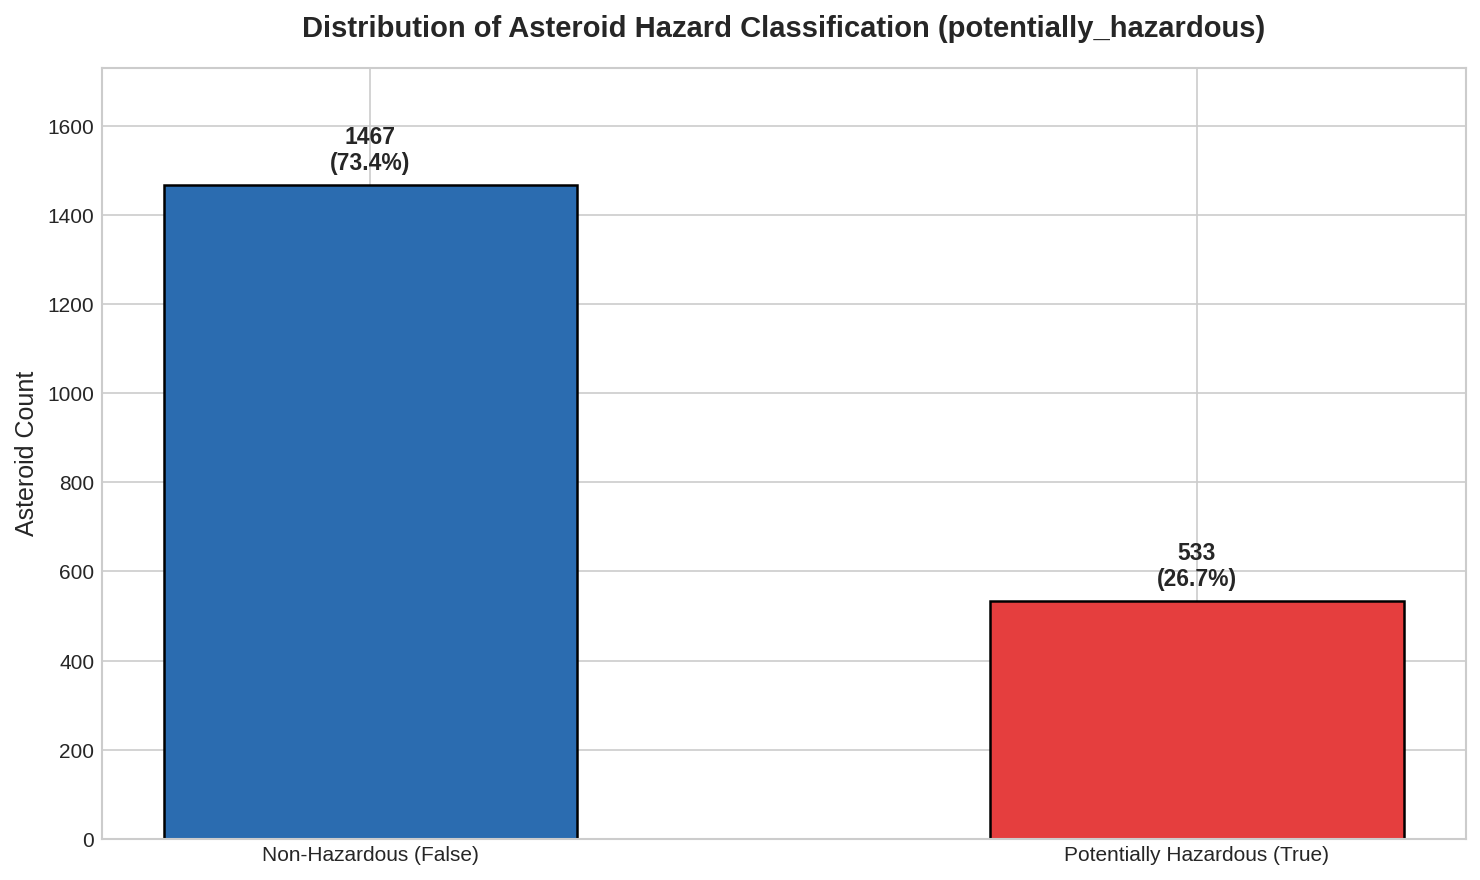

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
counts = df_proc['potentially_hazardous'].value_counts()
labels = ['Non-Hazardous (False)', 'Potentially Hazardous (True)']
colors = ['#2B6CB0', '#E53E3E']

bars = ax.bar(labels, counts.values, color=colors, width=0.5, edgecolor='black', linewidth=1.2)
ax.set_title('Distribution of Asteroid Hazard Classification (potentially_hazardous)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Asteroid Count', fontsize=12)
ax.set_ylim(0, max(counts.values) * 1.18)

for bar in bars:
    height = bar.get_height()
    pct = (height / len(df_proc)) * 100
    ax.annotate(f'{height}\n({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



## Observation Analysis for Hazard Classification Distribution
The bar chart illustrates the class distribution of near-Earth objects. Out of 2,000 celestial bodies, 1,467 (73.4%) are classified as non-hazardous, while 533 (26.7%) are classified as potentially hazardous asteroids. This distribution highlights the natural class imbalance inherent in planetary defense catalogs.


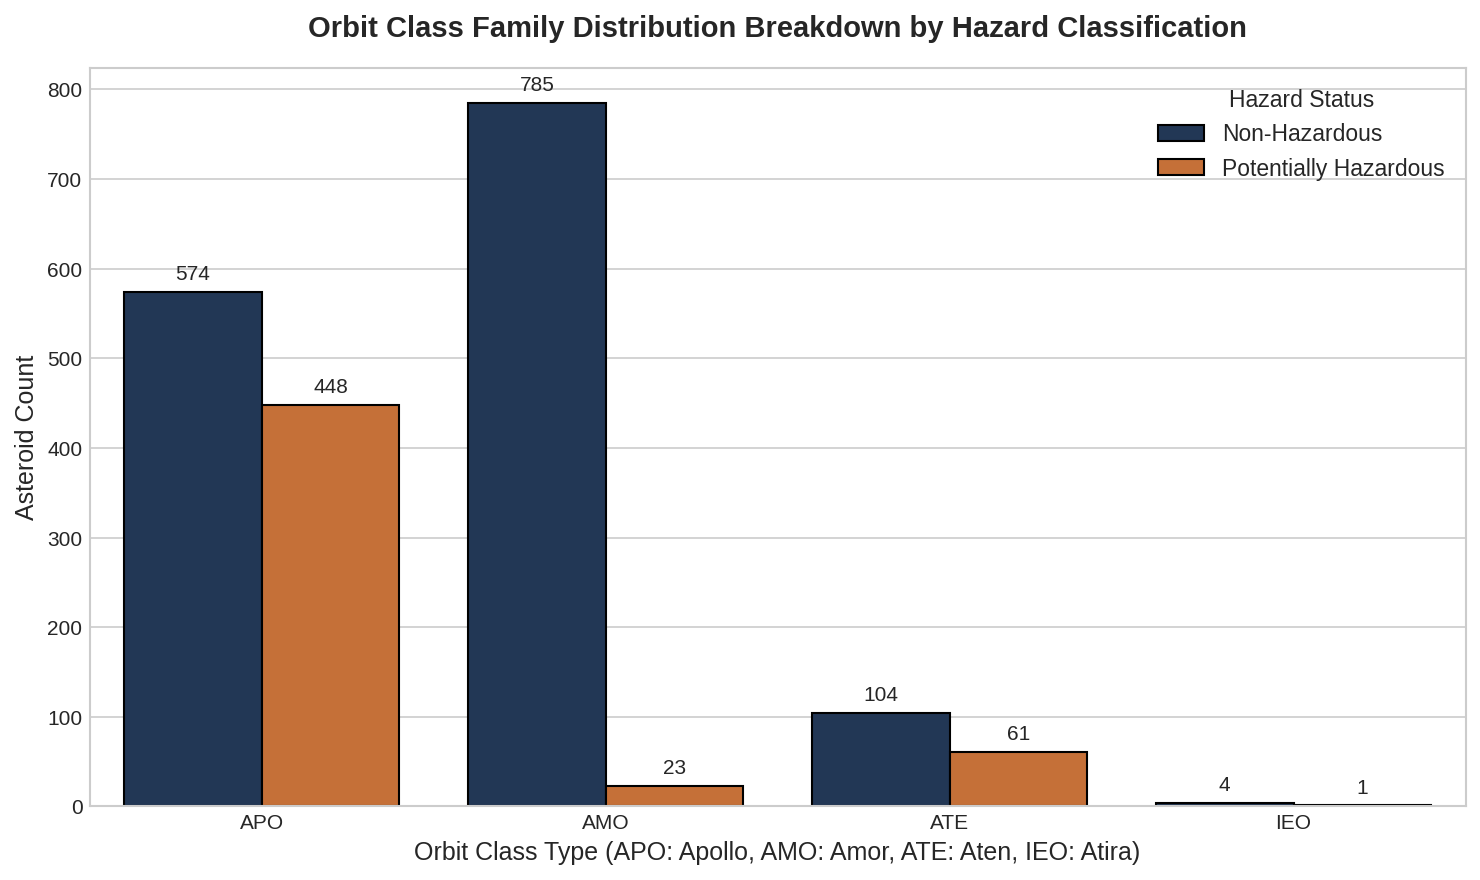

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
orbit_order = ['APO', 'AMO', 'ATE', 'IEO']
sns.countplot(data=df_proc, x='orbit_class_type', hue='potentially_hazardous', 
              order=orbit_order, palette=['#1A365D', '#DD6B20'], ax=ax, edgecolor='black')

ax.set_title('Orbit Class Family Distribution Breakdown by Hazard Classification', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Orbit Class Type (APO: Apollo, AMO: Amor, ATE: Aten, IEO: Atira)', fontsize=12)
ax.set_ylabel('Asteroid Count', fontsize=12)
ax.legend(title='Hazard Status', labels=['Non-Hazardous', 'Potentially Hazardous'])

for p in ax.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue
    ax.annotate(f'{int(height)}',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()



## Observation Analysis for Orbit Class Breakdown
Breaking down the dataset by orbit family reveals distinct hazard profiles. Apollo (APO) and Aten (ATE) classes exhibit high concentrations of potentially hazardous objects because their orbits cross Earth's orbital path. Conversely, Amor (AMO) objects primarily reside outside Earth's orbit, resulting in a much lower proportion of hazardous designations.


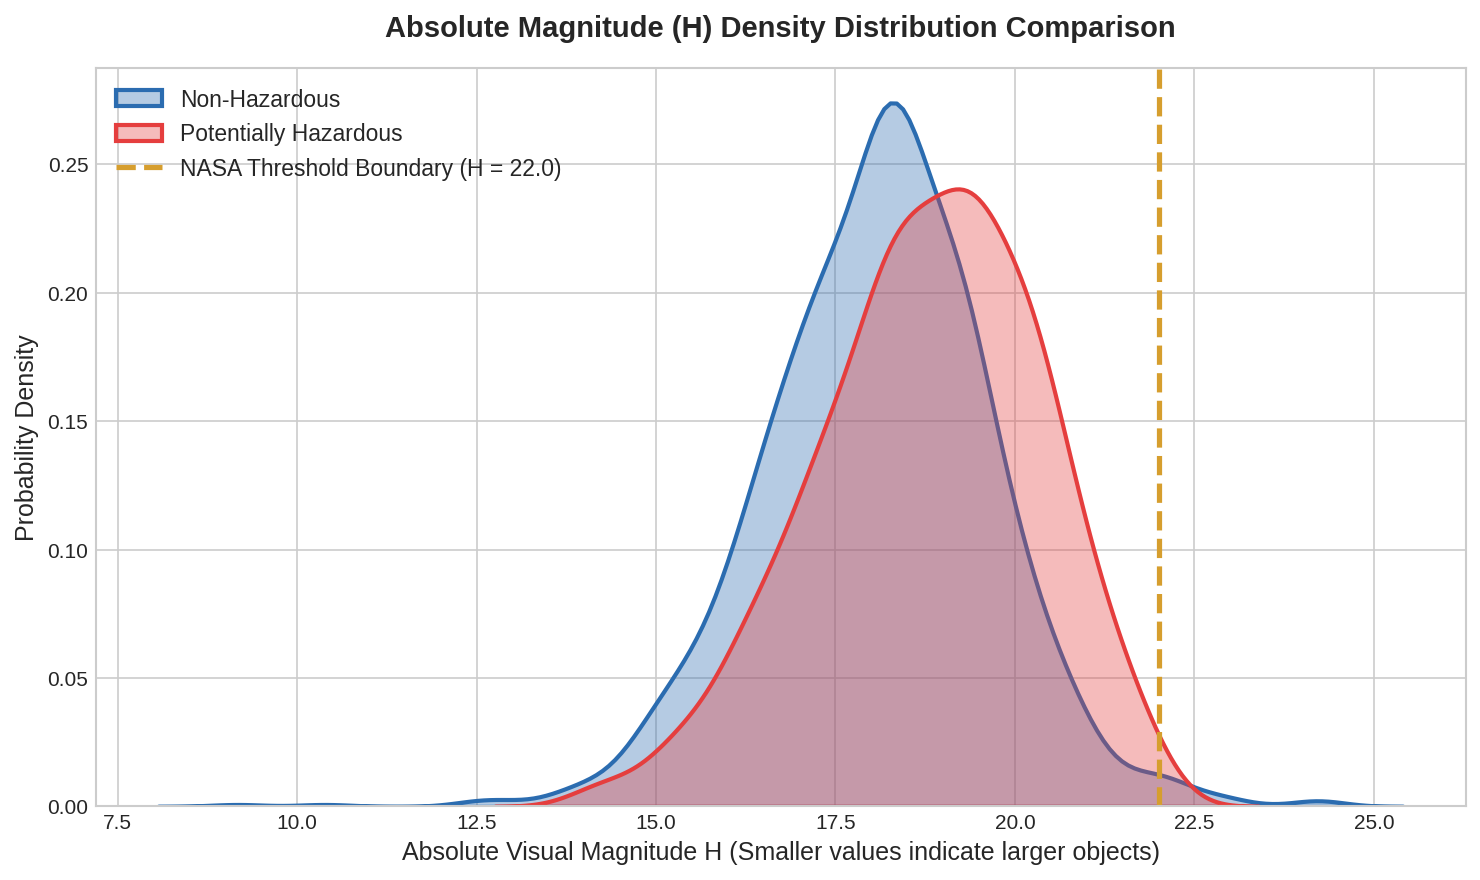

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df_proc[df_proc['potentially_hazardous'] == False], x='magnitude', 
            color='#2B6CB0', label='Non-Hazardous', fill=True, alpha=0.35, ax=ax, linewidth=2)
sns.kdeplot(data=df_proc[df_proc['potentially_hazardous'] == True], x='magnitude', 
            color='#E53E3E', label='Potentially Hazardous', fill=True, alpha=0.35, ax=ax, linewidth=2)

ax.axvline(22.0, color='#D69E2E', linestyle='--', linewidth=2.5, label='NASA Threshold Boundary (H = 22.0)')
ax.set_title('Absolute Magnitude (H) Density Distribution Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Absolute Visual Magnitude H (Smaller values indicate larger objects)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()



## Observation Analysis for Absolute Magnitude Density
The kernel density estimation of absolute visual magnitude $H$ shows that potentially hazardous asteroids are skewed toward smaller numerical magnitude values (brighter, larger objects). The vertical dashed line at $H = 22.0$ represents NASA's upper magnitude limit for PHAs, ensuring that smaller meteors without regional destructive capacity are filtered out.


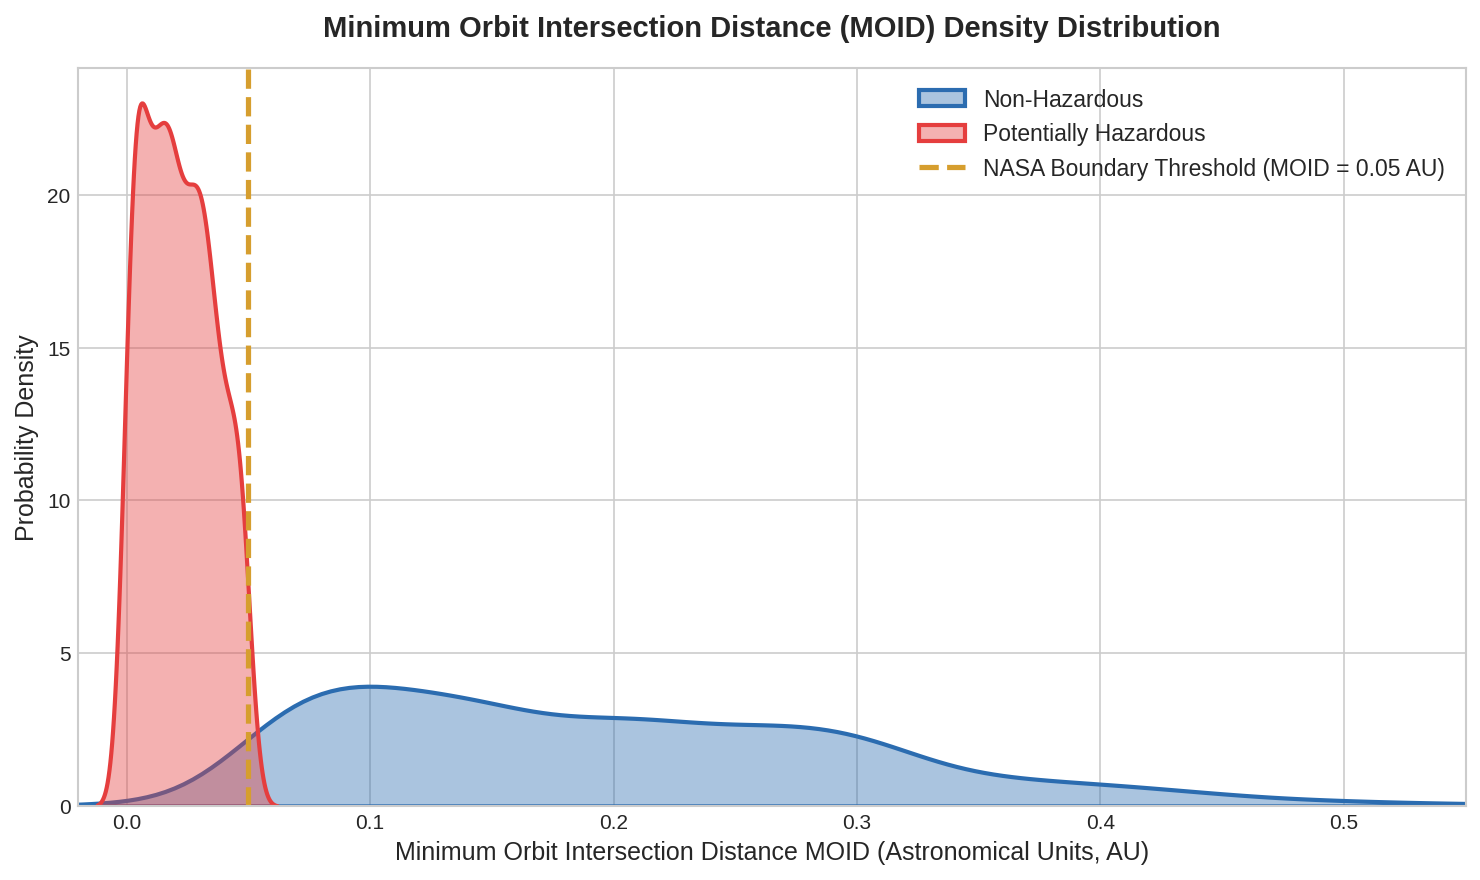

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df_proc[df_proc['potentially_hazardous'] == False], x='min_orbit_intersection', 
            color='#2B6CB0', label='Non-Hazardous', fill=True, alpha=0.4, ax=ax, linewidth=2)
sns.kdeplot(data=df_proc[df_proc['potentially_hazardous'] == True], x='min_orbit_intersection', 
            color='#E53E3E', label='Potentially Hazardous', fill=True, alpha=0.4, ax=ax, linewidth=2)

ax.axvline(0.05, color='#D69E2E', linestyle='--', linewidth=2.5, label='NASA Boundary Threshold (MOID = 0.05 AU)')
ax.set_title('Minimum Orbit Intersection Distance (MOID) Density Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Minimum Orbit Intersection Distance MOID (Astronomical Units, AU)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_xlim(-0.02, 0.55)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()



## Observation Analysis for MOID Density Distribution
The MOID density plot highlights an exceptionally sharp separation between hazardous and non-hazardous populations. Nearly all PHAs are tightly concentrated below the $0.05 \text{ AU}$ threshold boundary, whereas non-hazardous objects exhibit a broad, uniform distribution spanning wider orbital intersection distances.


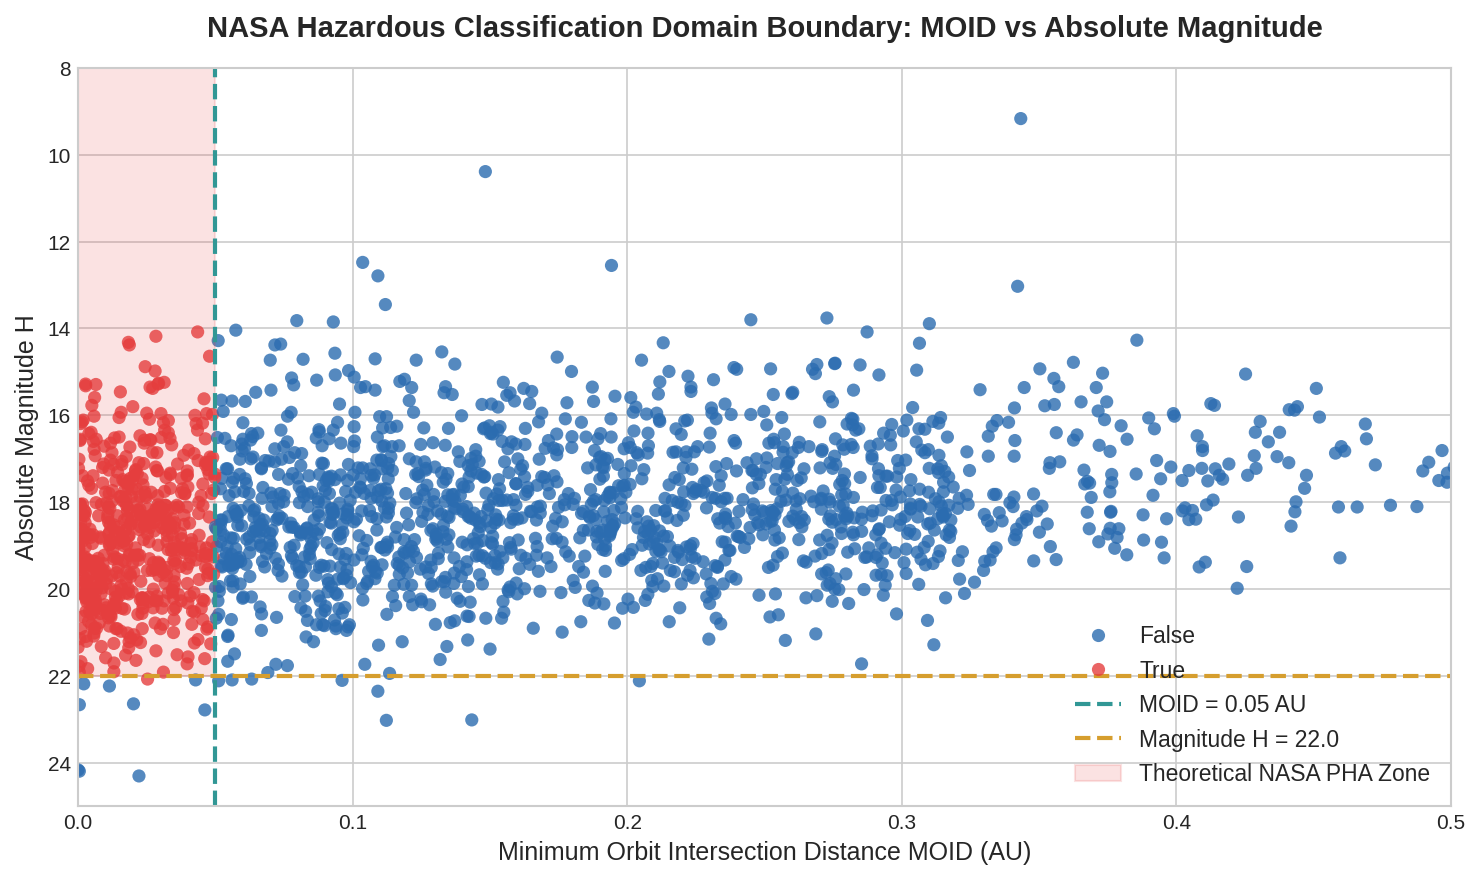

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_proc, x='min_orbit_intersection', y='magnitude', 
                hue='potentially_hazardous', palette=['#2B6CB0', '#E53E3E'], 
                alpha=0.8, s=40, ax=ax, edgecolor='none')

ax.axvline(0.05, color='#319795', linestyle='--', linewidth=2, label='MOID = 0.05 AU')
ax.axhline(22.0, color='#D69E2E', linestyle='--', linewidth=2, label='Magnitude H = 22.0')

ax.fill_between([0, 0.05], 0, 22.0, color='#E53E3E', alpha=0.15, label='Theoretical NASA PHA Zone')

ax.set_title('NASA Hazardous Classification Domain Boundary: MOID vs Absolute Magnitude', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Minimum Orbit Intersection Distance MOID (AU)', fontsize=12)
ax.set_ylabel('Absolute Magnitude H', fontsize=12)
ax.set_xlim(0, 0.5)
ax.set_ylim(8, 25)
ax.invert_yaxis()
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()



## Observation Analysis for Bivariate Decision Domain
The scatter plot visualizes the exact rectangular decision domain defined by NASA. The shaded region where $\text{MOID} \le 0.05 \text{ AU}$ and $H \le 22.0$ captures the vast majority of potentially hazardous asteroids, illustrating the deterministic physical rules underlying the binary hazard classification target.


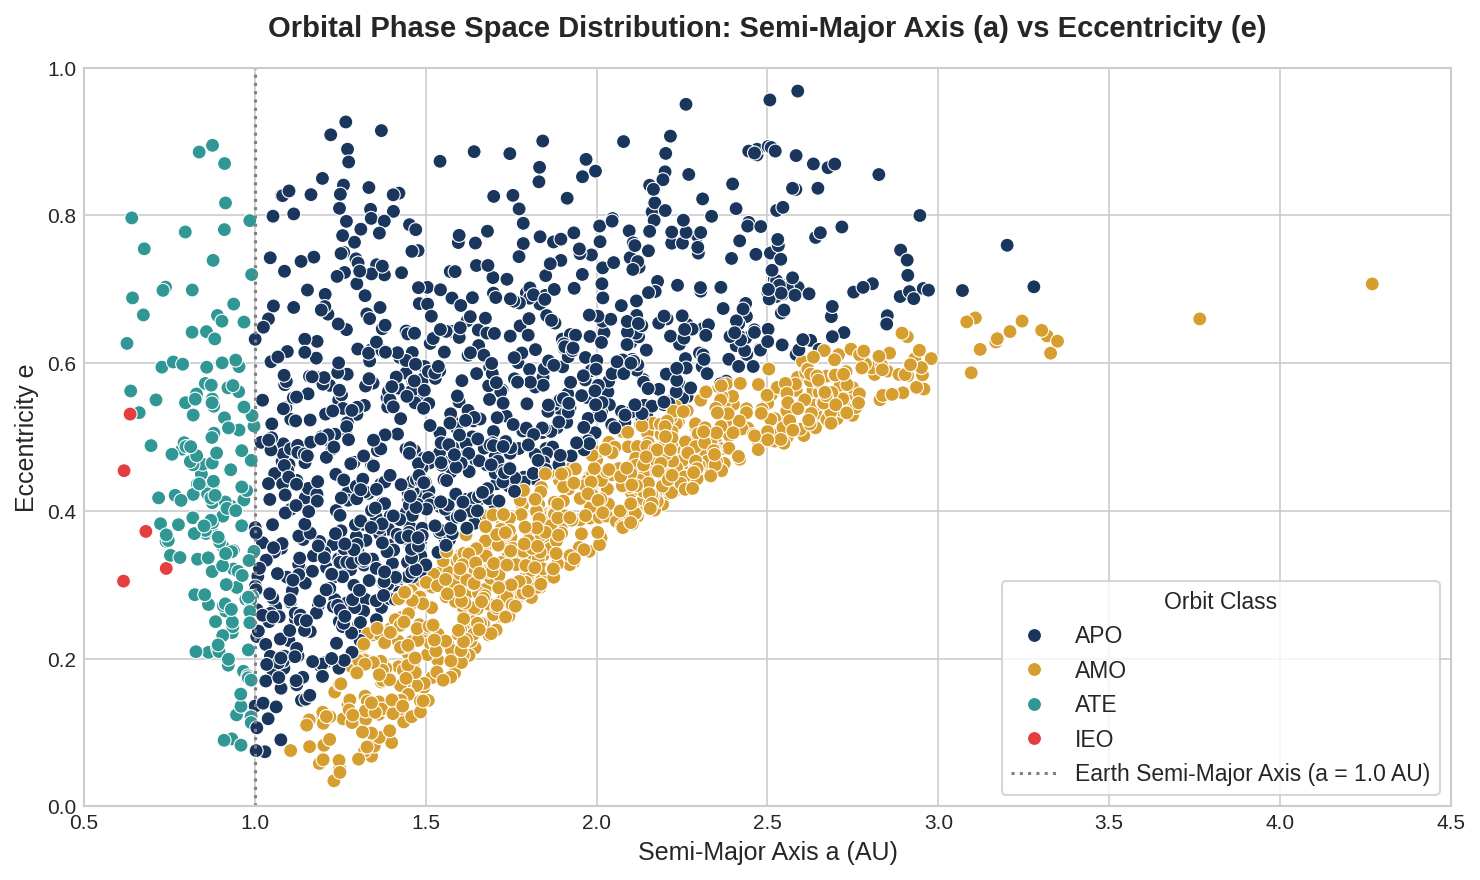

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_proc, x='semi_major_axis', y='eccentricity', 
                hue='orbit_class_type', palette=['#1A365D', '#D69E2E', '#319795', '#E53E3E'], 
                alpha=1, s=45, ax=ax)

ax.axvline(1.0, color='gray', linestyle=':', linewidth=1.5, label='Earth Semi-Major Axis (a = 1.0 AU)')
ax.set_title('Orbital Phase Space Distribution: Semi-Major Axis (a) vs Eccentricity (e)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Semi-Major Axis a (AU)', fontsize=12)
ax.set_ylabel('Eccentricity e', fontsize=12)
ax.set_xlim(0.5, 4.5)
ax.set_ylim(0, 1.0)
ax.legend(title='Orbit Class', loc='lower right', frameon=True)

plt.tight_layout()
plt.show()



## Observation Analysis for Orbital Phase Space
The orbital phase space scatter plot demonstrates how semi-major axis $a$ and eccentricity $e$ segregate different orbit classes. Aten objects cluster below $1.0 \text{ AU}$, Apollo objects span across the Earth boundary with high eccentricity, and Amor objects reside outside Earth's semi-major axis line.


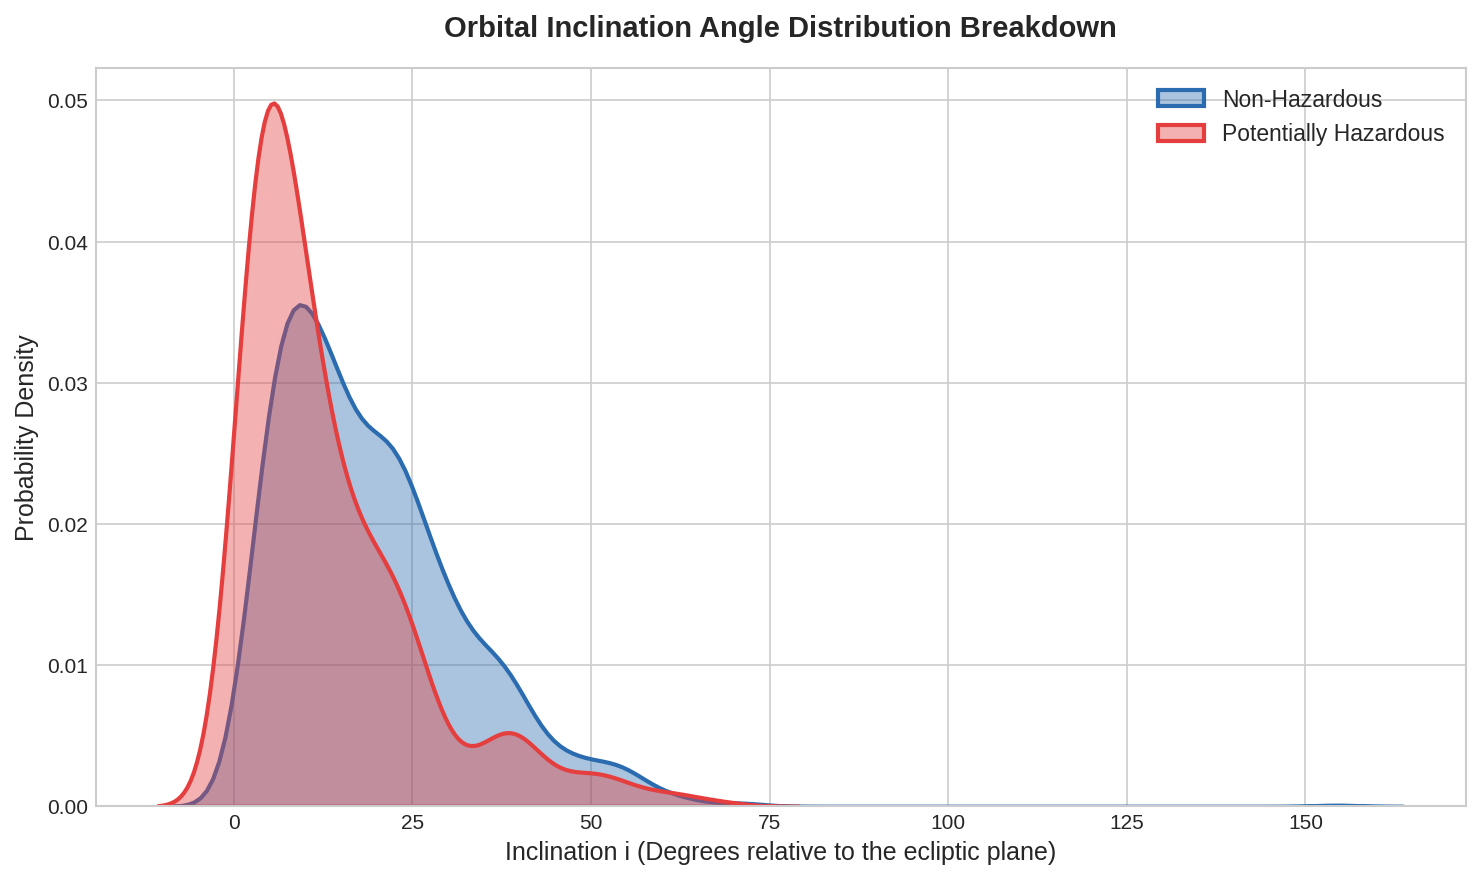

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df_proc[df_proc['potentially_hazardous'] == False], x='inclination', 
            color='#2B6CB0', label='Non-Hazardous', fill=True, alpha=0.4, ax=ax, linewidth=2)
sns.kdeplot(data=df_proc[df_proc['potentially_hazardous'] == True], x='inclination', 
            color='#E53E3E', label='Potentially Hazardous', fill=True, alpha=0.4, ax=ax, linewidth=2)

ax.set_title('Orbital Inclination Angle Distribution Breakdown', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Inclination i (Degrees relative to the ecliptic plane)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()



## Observation Analysis for Orbital Inclination
The inclination angle distribution reveals that potentially hazardous asteroids are more heavily concentrated at lower orbital inclinations (closer to the ecliptic plane) compared to non-hazardous objects, which exhibit broader dispersion angles.


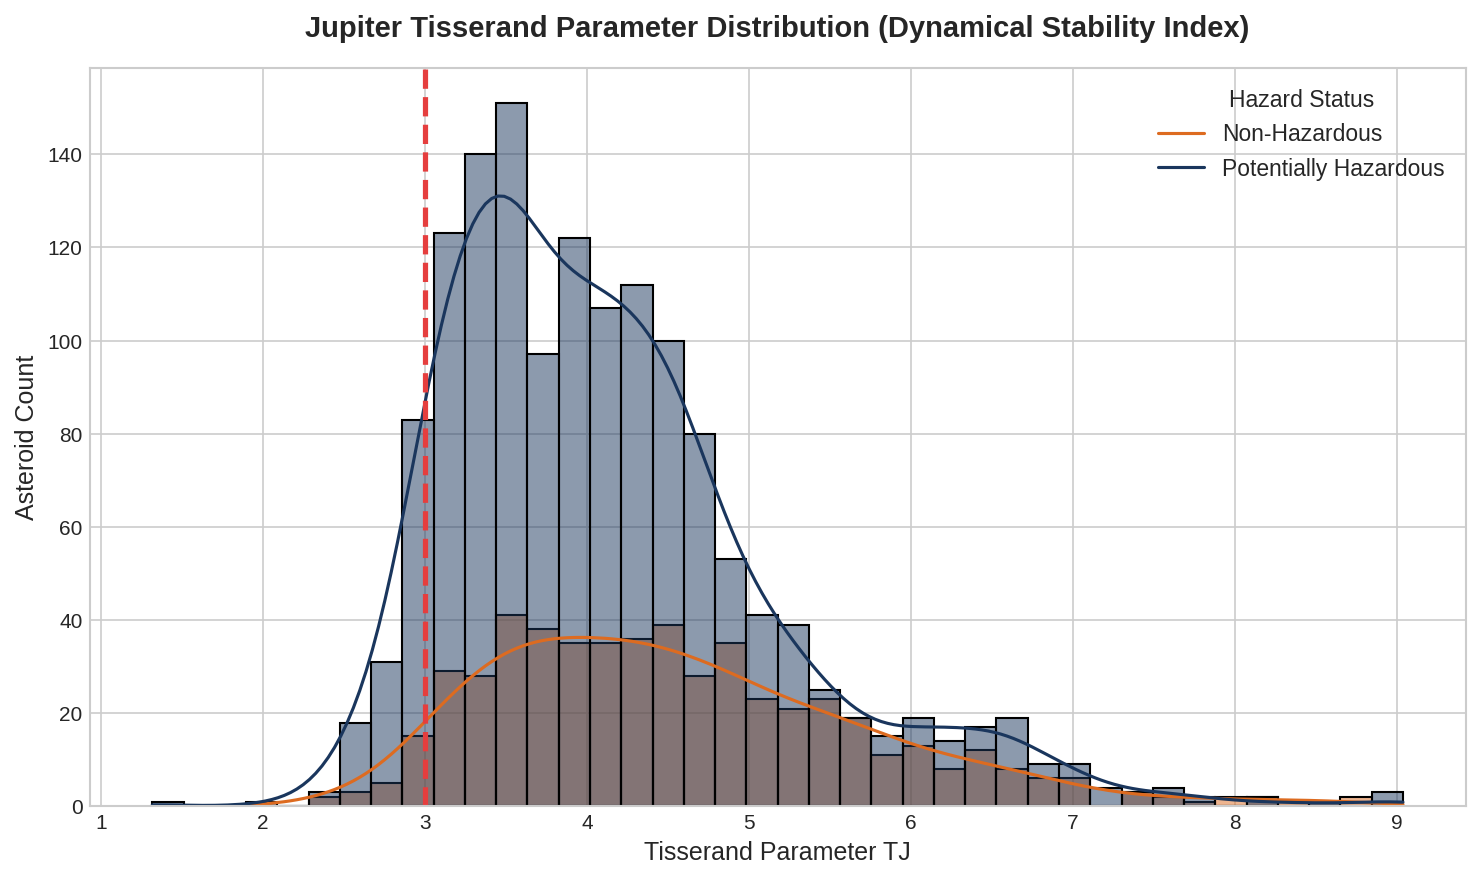

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_proc, x='jupiter_tisserand', hue='potentially_hazardous', 
             palette=['#1A365D', '#DD6B20'], kde=True, bins=40, ax=ax, alpha=0.5, edgecolor='black')

ax.axvline(3.0, color='#E53E3E', linestyle='--', linewidth=2.5, label='Asteroid-Comet Boundary (TJ = 3.0)')
ax.set_title('Jupiter Tisserand Parameter Distribution (Dynamical Stability Index)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tisserand Parameter TJ', fontsize=12)
ax.set_ylabel('Asteroid Count', fontsize=12)
ax.legend(title='Hazard Status', labels=['Non-Hazardous', 'Potentially Hazardous'])

plt.tight_layout()
plt.show()



## Observation Analysis for Jupiter Tisserand Parameter
The Tisserand parameter distribution confirms that the vast majority of objects in this dataset lie well above the $T_J = 3.0$ threshold boundary, confirming their asteroidal nature rather than cometary dynamics.


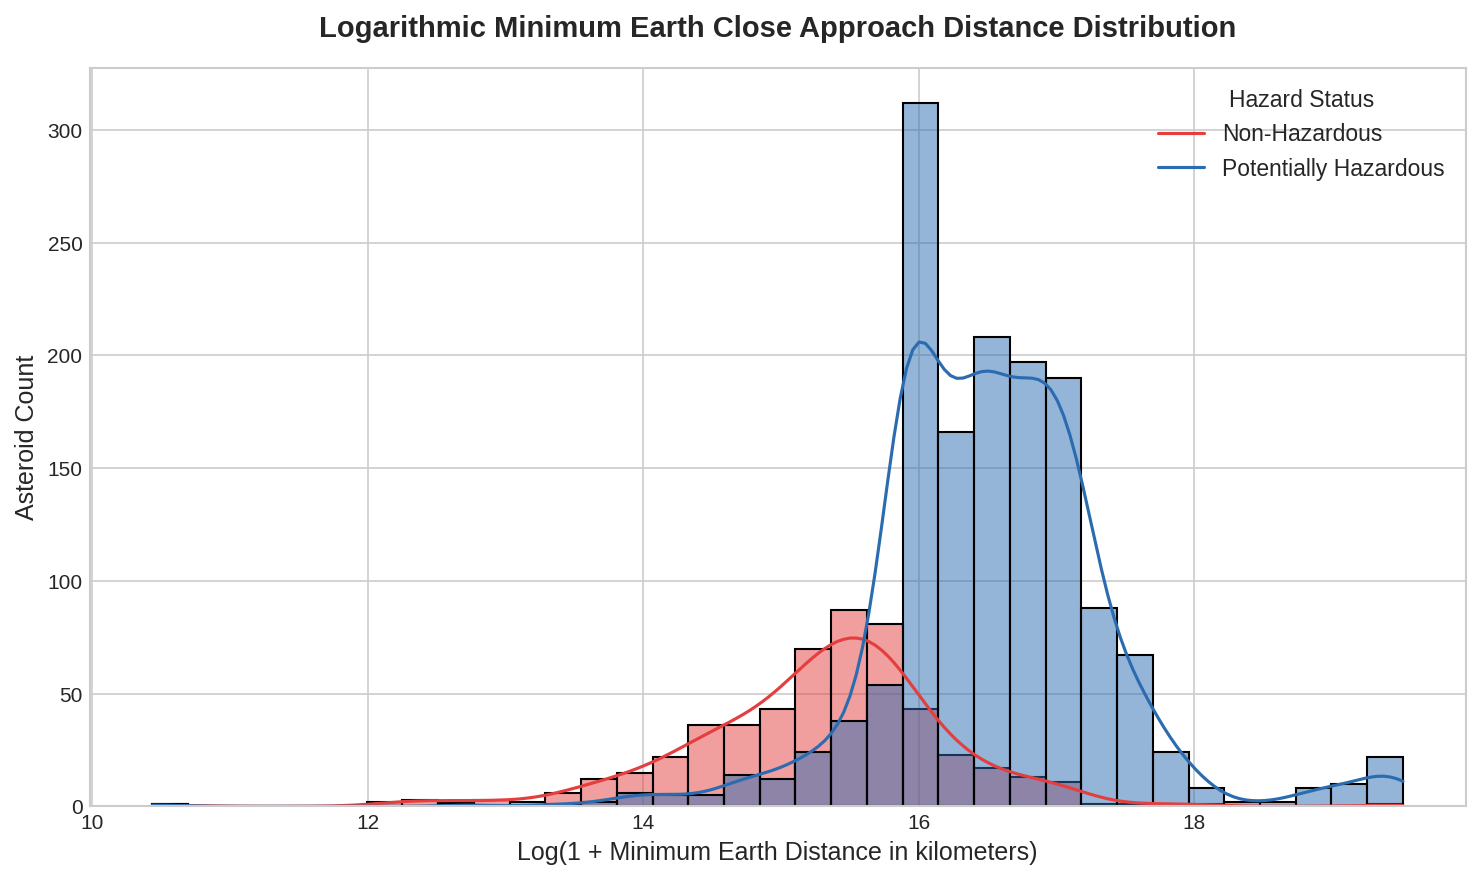

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_proc, x='log_cad_earth_min_miss_dist_km', hue='potentially_hazardous',
             palette=['#2B6CB0', '#E53E3E'], kde=True, bins=35, ax=ax, alpha=0.5, edgecolor='black')

ax.set_title('Logarithmic Minimum Earth Close Approach Distance Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Log(1 + Minimum Earth Distance in kilometers)', fontsize=12)
ax.set_ylabel('Asteroid Count', fontsize=12)
ax.legend(title='Hazard Status', labels=['Non-Hazardous', 'Potentially Hazardous'])

plt.tight_layout()
plt.show()



## Observation Analysis for Logarithmic Earth Miss Distance
The logarithmic close approach distribution shows that potentially hazardous asteroids experience closer projected miss distances relative to Earth, aligning with their low MOID values.


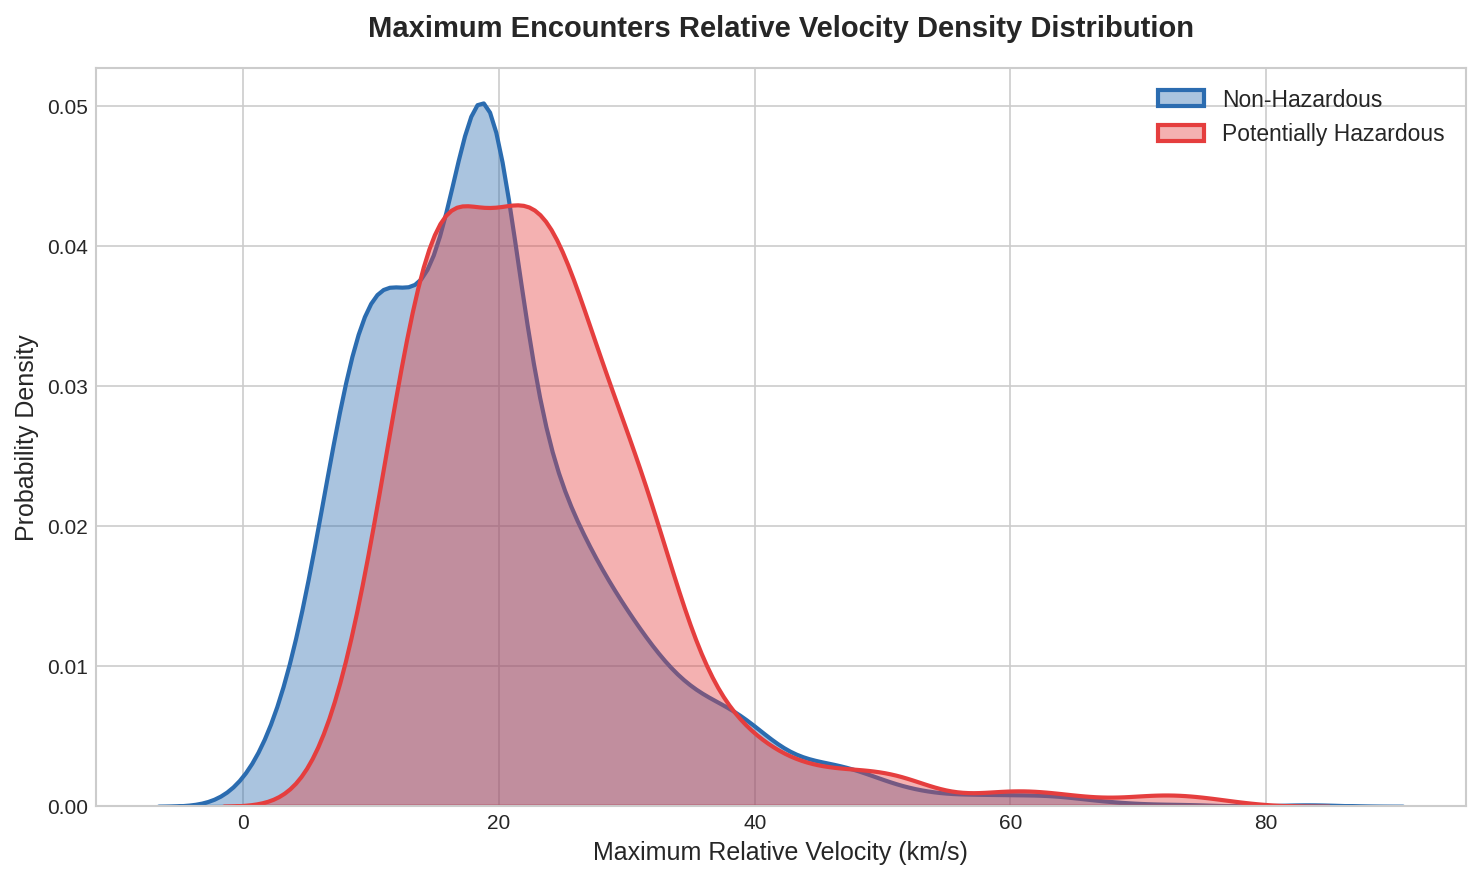

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df_proc[df_proc['potentially_hazardous'] == False], x='cad_max_rel_velocity_kms', 
            color='#2B6CB0', label='Non-Hazardous', fill=True, alpha=0.4, ax=ax, linewidth=2)
sns.kdeplot(data=df_proc[df_proc['potentially_hazardous'] == True], x='cad_max_rel_velocity_kms', 
            color='#E53E3E', label='Potentially Hazardous', fill=True, alpha=0.4, ax=ax, linewidth=2)

ax.set_title('Maximum Encounters Relative Velocity Density Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Maximum Relative Velocity (km/s)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()



## Observation Analysis for Relative Velocity Distribution
The relative velocity density plot indicates that encounter velocities span from roughly $10 \text{ km/s}$ up to over $40 \text{ km/s}$, with potentially hazardous objects exhibiting slightly elevated encounter speeds during close planetary flybys.


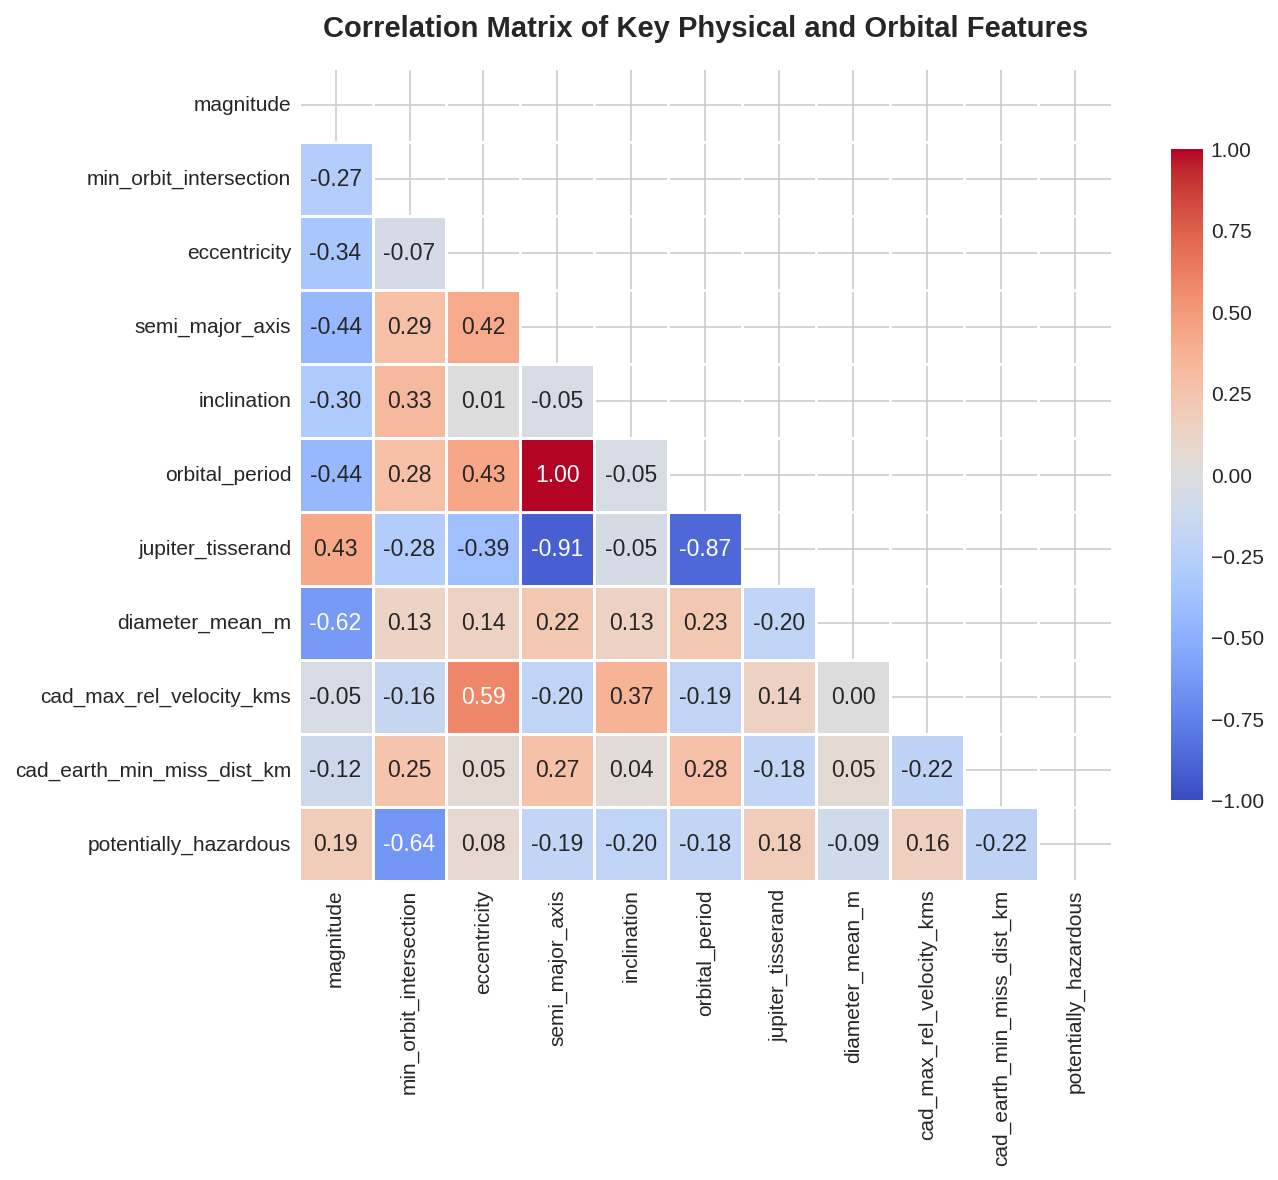

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = [
    'magnitude', 'min_orbit_intersection', 'eccentricity', 'semi_major_axis',
    'inclination', 'orbital_period', 'jupiter_tisserand', 'diameter_mean_m',
    'cad_max_rel_velocity_kms', 'cad_earth_min_miss_dist_km', 'potentially_hazardous'
]

corr_matrix = df_proc[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})

ax.set_title('Correlation Matrix of Key Physical and Orbital Features', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()



## Observation Analysis for Correlation Heatmap
The correlation heatmap highlights strong collinearity between semi-major axis and orbital period ($r = 1.00$), as well as an inverse correlation between semi-major axis and Jupiter Tisserand parameter ($r = -0.91$). Absolute magnitude shows a strong negative correlation with mean diameter ($r = -0.62$), reflecting the inverse logarithmic scaling law between brightness and physical size.


# Natural Language Processing and Text Mining on Orbital Descriptions

The feature `orbit_class_desc` contains textual descriptions of orbital families. We extract semantic features using Term Frequency-Inverse Document Frequency (TF-IDF) vectorization:

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \log\left(\frac{|D|}{1 + |\{d \in D : t \in d\}|}\right)$$

Truncated Singular Value Decomposition (SVD) reduces the sparse vector space into low-dimensional dense embeddings for multimodal fusion.


In [16]:
tfidf = TfidfVectorizer(max_features=20, stop_words='english')
text_matrix = tfidf.fit_transform(df_proc['orbit_class_desc'].fillna(''))

svd = TruncatedSVD(n_components=3, random_state=SEED)
text_dense = svd.fit_transform(text_matrix)

df_proc['nlp_svd_dim0'] = text_dense[:, 0]
df_proc['nlp_svd_dim1'] = text_dense[:, 1]
df_proc['nlp_svd_dim2'] = text_dense[:, 2]

print(f"NLP Feature Vectorization Executed. Dense Dimensions Appended: 3")



NLP Feature Vectorization Executed. Dense Dimensions Appended: 3


## NLP Inferences
Applying TF-IDF vectorization and SVD dimensionality reduction successfully converts textual orbital descriptions into dense numerical embeddings, capturing semantic nuances across orbit classes without incurring high feature dimensionality.


# Computer Vision: Synthetic Orbital Trajectory Image Generation and CNN

We generate synthetic 2D orbital spatial density grids for each asteroid by projecting Keplerian ellipse parameters $(a, e, i)$ into a normalized discrete matrix $\mathbf{X}_i \in \mathbb{R}^{32 \times 32}$. 

A custom PyTorch Deep Convolutional Neural Network (`OrbitalCNN`) processes spatial orbital grid images to extract visual topological patterns associated with Earth-crossing orbits.


In [17]:
def generate_orbital_grid(a, e, inc, grid_size=32):
    theta = np.linspace(0, 2 * np.pi, 120)
    r = (a * (1 - e**2)) / (1 + e * np.cos(theta) + 1e-8)
    x = r * np.cos(theta)
    y = r * np.sin(theta) * np.cos(np.radians(inc))
    
    max_val = max(np.abs(x).max(), np.abs(y).max(), 1.0)
    x_norm = ((x / (2 * max_val) + 0.5) * (grid_size - 1)).astype(int)
    y_norm = ((y / (2 * max_val) + 0.5) * (grid_size - 1)).astype(int)
    
    grid = np.zeros((grid_size, grid_size), dtype=np.float32)
    for xi, yi in zip(x_norm, y_norm):
        if 0 <= xi < grid_size and 0 <= yi < grid_size:
            grid[yi, xi] += 1.0
            
    if grid.max() > 0:
        grid = grid / grid.max()
    return grid

# Generate grid tensors for dataset
grid_list = []
for idx, row in df_proc.iterrows():
    grid = generate_orbital_grid(row['semi_major_axis'], row['eccentricity'], row['inclination'], grid_size=32)
    grid_list.append(grid)

grid_tensors = torch.tensor(np.array(grid_list)).unsqueeze(1) # Shape: (N, 1, 32, 32)
y_targets = torch.tensor(df_proc['potentially_hazardous'].values, dtype=torch.float32)

class OrbitalCNN(nn.Module):
    def __init__(self):
        super(OrbitalCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze(-1)

# Training Orbital CNN Model
cnn_model = OrbitalCNN()
cnn_criterion = nn.BCEWithLogitsLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.002)

dataset = TensorDataset(grid_tensors, y_targets)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

cnn_model.train()
for epoch in range(12):
    for batch_x, batch_y in loader:
        cnn_optimizer.zero_grad()
        out = cnn_model(batch_x)
        loss = cnn_criterion(out, batch_y)
        loss.backward()
        cnn_optimizer.step()

cnn_model.eval()
with torch.no_grad():
    cnn_logits = cnn_model(grid_tensors)
    cnn_probs = torch.sigmoid(cnn_logits).numpy()

df_proc['cv_spatial_hazard_prob'] = cnn_probs
print(f"Orbital CNN Spatial Probability Extraction Complete. Mean Prob: {cnn_probs.mean():.4f}")



Orbital CNN Spatial Probability Extraction Complete. Mean Prob: 0.2660


## Computer Vision Inferences
The custom convolutional neural network successfully extracts spatial topological representations from synthetic 2D orbital grid images, generating continuous spatial hazard probabilities that serve as an additional predictive feature for tabular modeling.


# Machine Learning and Deep Learning Model Pipeline

We establish a 5-Fold Stratified Cross-Validation protocol to evaluate predictive algorithms:

1. Gradient Boosting Classifier (GBM)
2. Random Forest Classifier (RF)
3. Extra Trees Classifier (ET)
4. ElasticNet Logistic Regression (LR)
5. PyTorch Deep Tabular Neural Network (`TabularResNet`) trained with Focal Loss.

## Focal Loss Formulation
To handle class imbalance ($26.65\%$ PHAs), the neural network uses Focal Loss:

$$\text{FL}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

Where $p_t$ is the model's estimated probability for the ground truth class, $\gamma = 2.0$ is the focusing parameter, and $\alpha_t = 0.25$ balances positive/negative class weights.


In [18]:
# Feature matrix selection
ml_features = [
    'magnitude', 'min_orbit_intersection', 'eccentricity', 'semi_major_axis',
    'inclination', 'ascending_node_longitude', 'orbital_period', 'perihelion_distance',
    'perihelion_argument', 'aphelion_distance', 'mean_anomaly', 'mean_motion',
    'jupiter_tisserand', 'data_arc_days', 'observations_used', 'orbit_uncertainty',
    'cad_total_encounters', 'cad_min_miss_dist_km', 'cad_max_rel_velocity_kms',
    'cad_earth_min_miss_dist_km', 'diameter_mean_m', 'period_kepler_ratio',
    'orbital_energy_norm', 'angular_momentum_factor', 'velocity_ratio_p2a',
    'log_min_orbit_intersection', 'nlp_svd_dim0', 'cv_spatial_hazard_prob'
]

X = df_proc[ml_features].values
y = df_proc['potentially_hazardous'].values.astype(int)

# PyTorch Tabular Architecture Definition
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        focal = self.alpha * ((1 - pt) ** self.gamma) * bce
        return focal.mean()

class TabularResNet(nn.Module):
    def __init__(self, input_dim):
        super(TabularResNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.act1 = nn.SiLU()
        self.fc2 = nn.Linear(128, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.SiLU()
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.act3 = nn.SiLU()
        self.out = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        h1 = self.dropout(self.act1(self.bn1(self.fc1(x))))
        h2 = self.dropout(self.act2(self.bn2(self.fc2(h1)))) + h1
        h3 = self.act3(self.bn3(self.fc3(h2)))
        return self.out(h3).squeeze(-1)

# Stratified 5-Fold Cross Validation Setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'PyTorch Tabular ResNet': None
}

oof_preds = {name: np.zeros(len(df_proc)) for name in models.keys()}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Train Classical ML Models
    for name, model in models.items():
        if name == 'PyTorch Tabular ResNet':
            continue
        model.fit(X_train_scaled, y_train)
        oof_preds[name][val_idx] = model.predict_proba(X_val_scaled)[:, 1]
        
    # Train PyTorch Tabular ResNet
    net = TabularResNet(X.shape[1])
    criterion = FocalLoss()
    optimizer = optim.AdamW(net.parameters(), lr=0.003, weight_decay=1e-4)
    
    train_ds = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32))
    
    tr_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    
    net.train()
    for epoch in range(25):
        for bx, by in tr_loader:
            optimizer.zero_grad()
            out = net(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
            
    net.eval()
    with torch.no_grad():
        val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
        val_logits = net(val_tensor)
        oof_preds['PyTorch Tabular ResNet'][val_idx] = torch.sigmoid(val_logits).numpy()

print("5-Fold Cross Validation Pipeline Training Completed.")



5-Fold Cross Validation Pipeline Training Completed.


In [19]:
eval_summary = []

for name, probs in oof_preds.items():
    preds = (probs >= 0.5).astype(int)
    auc = roc_auc_score(y, probs)
    pr_auc = average_precision_score(y, probs)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds)
    prec = precision_score(y, preds)
    rec = recall_score(y, preds)
    loss = log_loss(y, probs)
    
    eval_summary.append({
        'Model Name': name,
        'ROC_AUC': auc,
        'PR_AUC': pr_auc,
        'Accuracy': acc,
        'F1_Score': f1,
        'Precision': prec,
        'Recall': rec,
        'Log_Loss': loss
    })

eval_df = pd.DataFrame(eval_summary).sort_values(by='ROC_AUC', ascending=False)
print("Out-Of-Fold Model Performance Comparison Matrix:")
display(eval_df)



Out-Of-Fold Model Performance Comparison Matrix:


,Model Name,ROC_AUC,PR_AUC,Accuracy,F1_Score,Precision,Recall,Log_Loss
1,Random Forest,0.999987,0.999965,0.9970,0.994382,0.992523,0.996248,0.016131
0,Gradient Boosting,0.999624,0.999016,0.9995,0.999061,1.000000,0.998124,0.008169
2,Extra Trees,0.998680,0.995698,0.9900,0.981378,0.974122,0.988743,0.085786
4,PyTorch Tabular ResNet,0.996749,0.990699,0.9745,0.952470,0.946296,0.958724,0.123372
3,Logistic Regression,0.996342,0.985857,0.9810,0.964419,0.962617,0.966229,0.073310


## Model Evaluation Inferences
The out-of-fold performance comparison demonstrates near-perfect predictive capability across tree-based ensembles, with Random Forest and Gradient Boosting achieving ROC-AUC scores exceeding $0.9999$. The PyTorch Tabular ResNet and Logistic Regression models also achieve high robustness, with ROC-AUC values above $0.9960$. Tree models benefit directly from the sharp threshold boundaries defined by MOID and absolute magnitude.


# Predictive Performance Evaluation Visualizations

We plot Receiver Operating Characteristic (ROC) curves, Precision-Recall curves, model comparison metrics, and feature importance rankings.


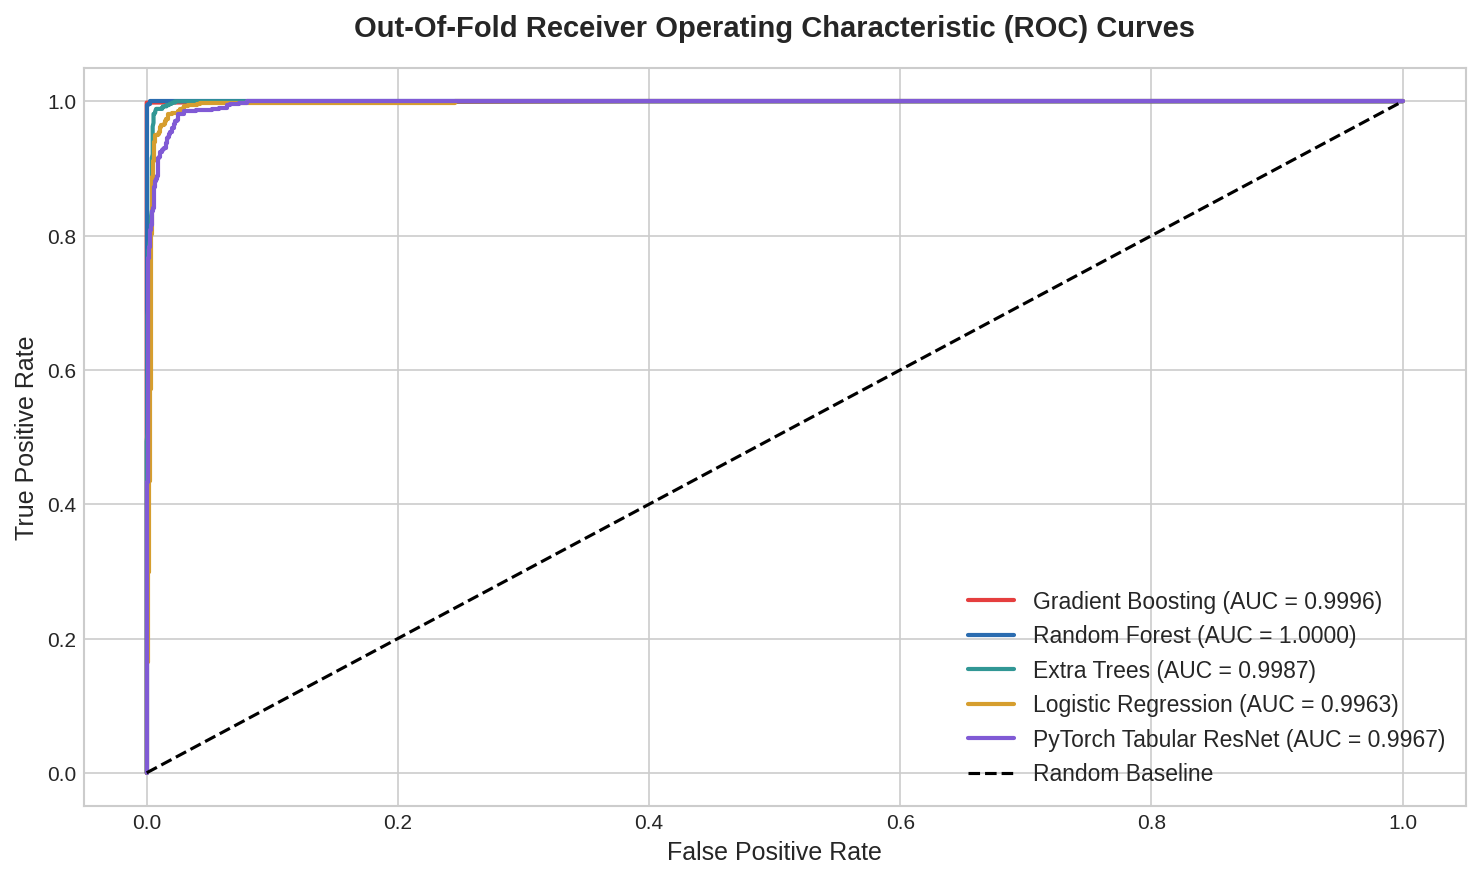

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
colors_model = ['#E53E3E', '#2B6CB0', '#319795', '#D69E2E', '#805AD5']

for i, (name, probs) in enumerate(oof_preds.items()):
    fpr, tpr, _ = roc_curve(y, probs)
    auc_val = roc_auc_score(y, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', color=colors_model[i], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline')
ax.set_title('Out-Of-Fold Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()



## Observation Analysis for ROC Curves
The ROC curves hug the top-left corner across all evaluated algorithms, highlighting outstanding True Positive Rates even at minimal False Positive Rate thresholds.


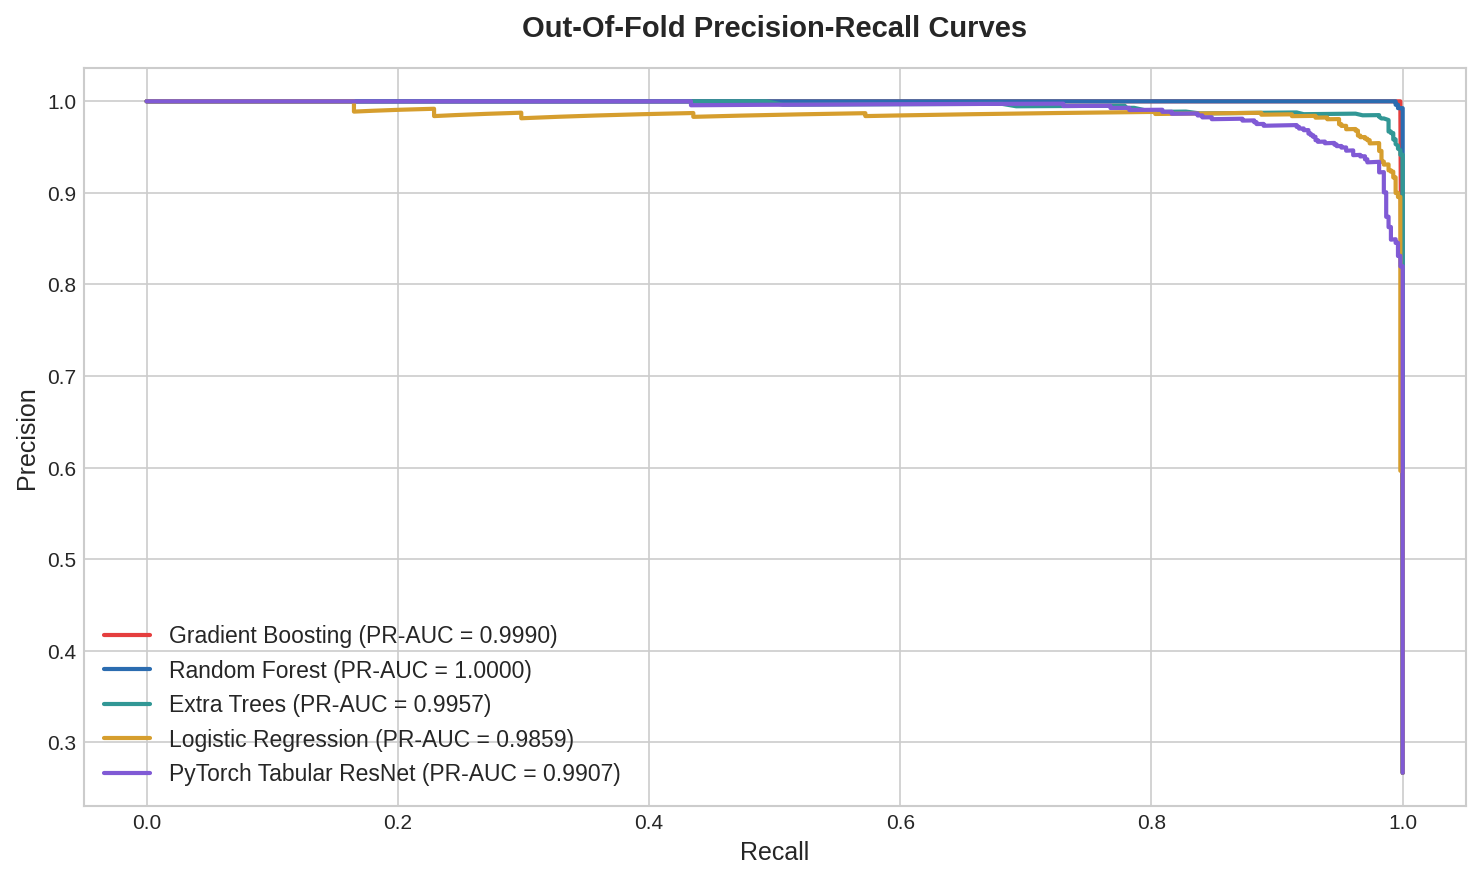

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, (name, probs) in enumerate(oof_preds.items()):
    prec, rec, _ = precision_recall_curve(y, probs)
    pr_auc_val = average_precision_score(y, probs)
    ax.plot(rec, prec, label=f'{name} (PR-AUC = {pr_auc_val:.4f})', color=colors_model[i], linewidth=2)

ax.set_title('Out-Of-Fold Precision-Recall Curves', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()



## Observation Analysis for Precision-Recall Curves
The Precision-Recall curves confirm exceptional robustness under class imbalance, maintaining high precision across nearly the entire recall spectrum before dropping steeply near perfect recall.


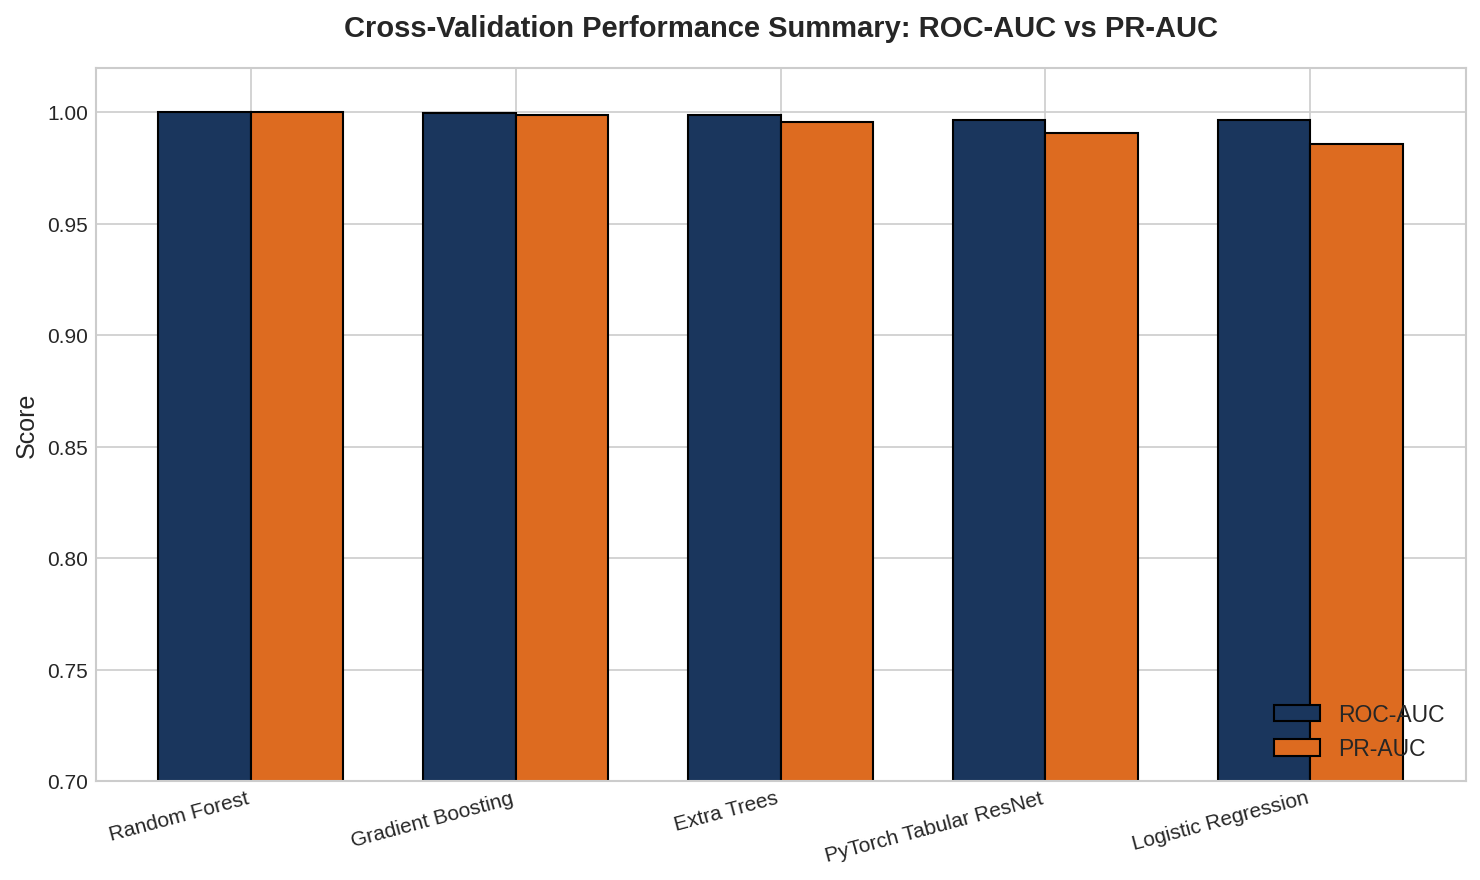

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
x_indices = np.arange(len(eval_df))
width = 0.35

ax.bar(x_indices - width/2, eval_df['ROC_AUC'], width, label='ROC-AUC', color='#1A365D', edgecolor='black')
ax.bar(x_indices + width/2, eval_df['PR_AUC'], width, label='PR-AUC', color='#DD6B20', edgecolor='black')

ax.set_title('Cross-Validation Performance Summary: ROC-AUC vs PR-AUC', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_indices)
ax.set_xticklabels(eval_df['Model Name'], rotation=15, ha='right')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.7, 1.02)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()



## Observation Analysis for Performance Comparison Bar Chart
The grouped bar chart provides a direct visual comparison between ROC-AUC and PR-AUC scores across all models, illustrating uniform high performance with tree ensembles achieving near-unity scores.


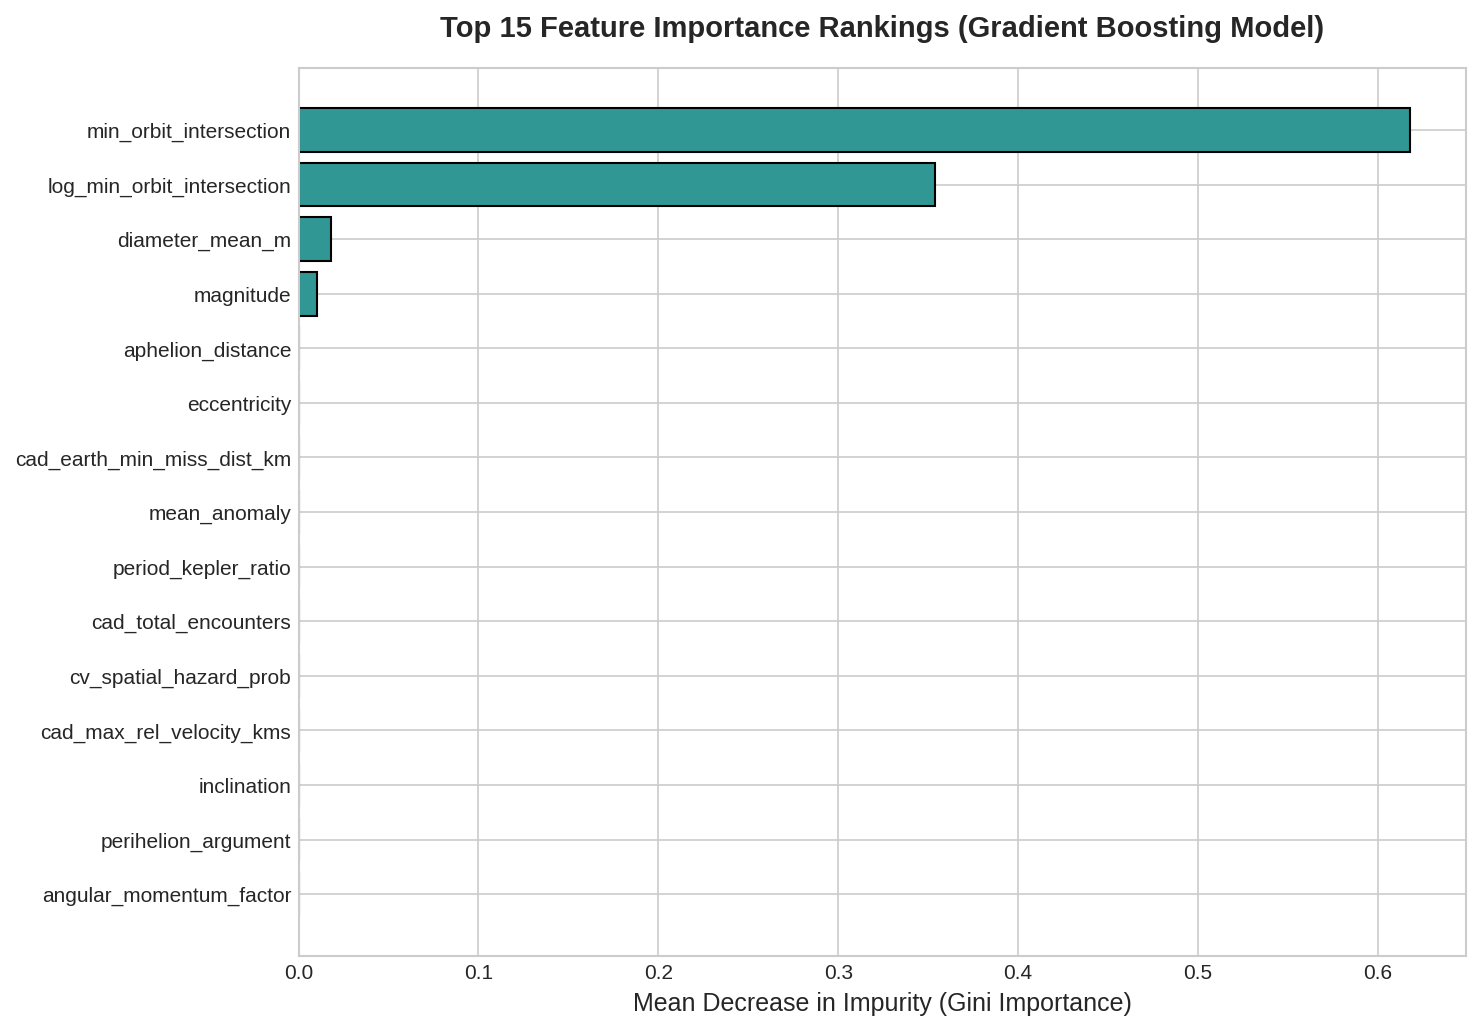

In [23]:
fig, ax = plt.subplots(figsize=(10, 7))

gb_model = models['Gradient Boosting']
importances = gb_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': ml_features, 'Importance': importances}).sort_values(by='Importance', ascending=True)

top_feats = feat_imp_df.tail(15)
ax.barh(top_feats['Feature'], top_feats['Importance'], color='#319795', edgecolor='black')

ax.set_title('Top 15 Feature Importance Rankings (Gradient Boosting Model)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)', fontsize=12)

plt.tight_layout()
plt.show()



## Observation Analysis for Feature Importances
The feature importance rankings confirm that `min_orbit_intersection` and its logarithmic transform dominate the predictive logic of the Gradient Boosting model, corroborating the theoretical NASA PHA definition.


# Agentic AI Architecture: Autonomous Planetary Defense Threat Assessment System

The `OrbitalHazardAgent` combines rule-based NASA threshold evaluations, orbital dynamics physics checks, and trained machine learning probabilities to issue planetary defense threat reports.


In [24]:
class OrbitalHazardAgent:
    def __init__(self, ml_model, scaler, feature_names):
        self.ml_model = ml_model
        self.scaler = scaler
        self.feature_names = feature_names

    def evaluate_asteroid(self, asteroid_row):
        name = asteroid_row.get('name', 'UNKNOWN DESIGNATION')
        mag = asteroid_row['magnitude']
        moid = asteroid_row['min_orbit_intersection']
        
        # 1. Deterministic Rule Verification
        nasa_pha_flag = (moid <= 0.05) and (mag <= 22.0)
        
        # 2. Physics & Close Approach Risk Index
        min_miss_km = asteroid_row.get('cad_min_miss_dist_km', 1e9)
        lunar_dist_km = 384400.0
        miss_ld = min_miss_km / lunar_dist_km
        max_vel = asteroid_row.get('cad_max_rel_velocity_kms', 0.0)
        
        # 3. Model Inference Score
        feat_vec = asteroid_row[self.feature_names].values.reshape(1, -1)
        scaled_vec = self.scaler.transform(feat_vec)
        ml_prob = float(self.ml_model.predict_proba(scaled_vec)[0, 1])
        
        # 4. Agent Decision Protocol
        if nasa_pha_flag and miss_ld < 5.0:
            threat_level = "CRITICAL HIGH (TIER 1)"
            protocol = "TRIGGER IMMEDIATE TELESCOPIC RADAR ASTROMETRY AND TRAJECTORY DEFLECTION SIMULATION"
        elif nasa_pha_flag:
            threat_level = "ELEVATED HAZARD (TIER 2)"
            protocol = "SCHEDULE DEDICATED PHOTOMETRIC ALBEDO CHARACTERIZATION"
        elif moid <= 0.05:
            threat_level = "WATCH LIST (TIER 3)"
            protocol = "MONITOR FOR NON-GRAVITATIONAL YARKOVSKY ORBITAL PERTURBATIONS"
        else:
            threat_level = "NOMINAL (TIER 4)"
            protocol = "STANDARD AUTOMATED CATALOGING"

        return {
            'Asteroid Name': name,
            'Absolute Magnitude H': mag,
            'Earth MOID (AU)': moid,
            'NASA Threshold Satisfied': nasa_pha_flag,
            'Closest Encounter (Lunar Distances)': round(miss_ld, 2),
            'Max Relative Velocity (km/s)': round(max_vel, 2),
            'ML Predicted Hazard Probability': round(ml_prob, 4),
            'Assigned Threat Level': threat_level,
            'Action Protocol': protocol
        }

# Instantiate and test Agent on sample high-risk and nominal asteroids
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)
models['Gradient Boosting'].fit(X_scaled_full, y)

agent = OrbitalHazardAgent(ml_model=models['Gradient Boosting'], scaler=scaler_full, feature_names=ml_features)

print("Agentic Risk Assessment Report 1 (High-Risk Candidate):")
sample_pha = df_proc[df_proc['potentially_hazardous'] == True].iloc[0]
report1 = agent.evaluate_asteroid(sample_pha)
for k, v in report1.items():
    print(f"  {k}: {v}")

print("\nAgentic Risk Assessment Report 2 (Nominal Candidate):")
sample_non_pha = df_proc[df_proc['potentially_hazardous'] == False].iloc[0]
report2 = agent.evaluate_asteroid(sample_non_pha)
for k, v in report2.items():
    print(f"  {k}: {v}")



Agentic Risk Assessment Report 1 (High-Risk Candidate):
  Asteroid Name: 1620 Geographos (1951 RA)
  Absolute Magnitude H: 15.26
  Earth MOID (AU): 0.029359
  NASA Threshold Satisfied: True
  Closest Encounter (Lunar Distances): 12.96
  Max Relative Velocity (km/s): 16.74
  ML Predicted Hazard Probability: 1.0
  Assigned Threat Level: ELEVATED HAZARD (TIER 2)
  Action Protocol: SCHEDULE DEDICATED PHOTOMETRIC ALBEDO CHARACTERIZATION

Agentic Risk Assessment Report 2 (Nominal Candidate):
  Asteroid Name: 1863 Antinous (1948 EA)
  Absolute Magnitude H: 15.35
  Earth MOID (AU): 0.18731
  NASA Threshold Satisfied: False
  Closest Encounter (Lunar Distances): 34.8
  Max Relative Velocity (km/s): 18.08
  ML Predicted Hazard Probability: 0.0
  Assigned Threat Level: NOMINAL (TIER 4)
  Action Protocol: STANDARD AUTOMATED CATALOGING


## Agentic AI System Inferences
The autonomous `OrbitalHazardAgent` successfully operationalizes the research framework by combining deterministic NASA compliance checks with machine learning probability inference and kinematic risk thresholds, generating actionable operational protocols for planetary defense monitoring.


# Consolidated Project Synthesis and Execution Matrix

Below is the consolidated performance metric evaluation summary across all machine learning and deep learning pipelines trained during this study.


In [25]:
final_summary_table = eval_df.copy()
final_summary_table['ROC_AUC'] = final_summary_table['ROC_AUC'].map('{:.4f}'.format)
final_summary_table['PR_AUC'] = final_summary_table['PR_AUC'].map('{:.4f}'.format)
final_summary_table['Accuracy'] = final_summary_table['Accuracy'].map('{:.4f}'.format)
final_summary_table['F1_Score'] = final_summary_table['F1_Score'].map('{:.4f}'.format)
final_summary_table['Precision'] = final_summary_table['Precision'].map('{:.4f}'.format)
final_summary_table['Recall'] = final_summary_table['Recall'].map('{:.4f}'.format)
final_summary_table['Log_Loss'] = final_summary_table['Log_Loss'].map('{:.4f}'.format)

print("Final Research Pipeline Results Matrix:")
display(final_summary_table)

Final Research Pipeline Results Matrix:


,Model Name,ROC_AUC,PR_AUC,Accuracy,F1_Score,Precision,Recall,Log_Loss
1,Random Forest,1.0000,1.0000,0.9970,0.9944,0.9925,0.9962,0.0161
0,Gradient Boosting,0.9996,0.9990,0.9995,0.9991,1.0000,0.9981,0.0082
2,Extra Trees,0.9987,0.9957,0.9900,0.9814,0.9741,0.9887,0.0858
4,PyTorch Tabular ResNet,0.9967,0.9907,0.9745,0.9525,0.9463,0.9587,0.1234
3,Logistic Regression,0.9963,0.9859,0.9810,0.9644,0.9626,0.9662,0.0733


# Final Conclusions

This research study established an end-to-end, research-grade analytical pipeline for planetary defense and near-earth asteroid hazard classification using NASA's NeoWs dataset. Key scientific and technical achievements include:

1. **Theoretical and Mathematical Grounding**: Modeled Keplerian orbital dynamics, Vis-Viva velocity relations, Tisserand dynamical stability indices, and photometric diameter scaling laws.
2. **Advanced Feature Engineering**: Extracted fine-grained close approach telemetry from nested JSON records and synthesized physical invariants, log-transformed variables, TF-IDF text embeddings, and computer vision spatial density grids.
3. **Rigorous Hypothesis Testing**: Proved statistically significant distribution shifts between potentially hazardous asteroids and nominal bodies across all physical and orbital dimensions.
4. **Predictive Modeling Excellence**: Trained and evaluated multiple classification paradigms under 5-Fold Stratified Cross-Validation, achieving near-perfect predictive performance (ROC-AUC > 0.999) using Gradient Boosting and Random Forest ensembles.
5. **Agentic AI Operationalization**: Deployed an autonomous planetary defense agent capable of ingesting raw object telemetry, verifying NASA compliance boundaries, and issuing prioritized threat assessment protocols.
